# 💻 Analisis Perbandingan Berbagai Algoritma Regresi dalam Estimasi Harga Jual Laptop Berdasarkan Spesifikasi Hardware

---

**Dataset :** `laptop_data.csv`  
**Target Variable :** `Price` (Harga Laptop — log-transformed)  
**Task :** Regression  
**Algoritma :** Random Forest Regressor, Decision Tree Regressor, K-Nearest Neighbors Regressor  
**Metrik Evaluasi :** MAE, MSE, RMSE, R² Score  

---

### 📋 Daftar Isi
1. [Data Understanding](#1)
2. [Data Preprocessing](#2)
3. [Exploratory Data Analysis (EDA)](#3)
4. [Data Splitting](#4)
5. [Model Building](#5)
6. [Hyperparameter Tuning](#6)
7. [Model Evaluation](#7)
8. [Model Comparison](#8)
9. [Inference — Estimasi Harga Laptop Baru](#9)

## 📦 Import Library

In [1]:
# ── Standar & Numerik ──────────────────────────────────────
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── Visualisasi ────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size']  = 10

# ── Preprocessing ──────────────────────────────────────────
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV

# ── Algoritma Regresi ──────────────────────────────────────
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree     import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor

# ── Evaluasi Regresi ───────────────────────────────────────
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ── Utilitas ───────────────────────────────────────────────
import pickle

print('✅ Semua library berhasil diimport!')
import sklearn
print(f'   pandas  : {pd.__version__}')
print(f'   numpy   : {np.__version__}')
print(f'   sklearn : {sklearn.__version__}')

✅ Semua library berhasil diimport!
   pandas  : 2.3.3
   numpy   : 2.2.3
   sklearn : 1.6.1


---
<a id='1'></a>
## 1️⃣ Data Understanding

### 1.1 Sumber Dataset
Dataset `laptop_data.csv` berisi informasi spesifikasi teknis laptop dari berbagai merek. Dataset ini digunakan untuk membangun model regresi yang dapat **mengestimasi harga jual laptop** berdasarkan spesifikasi hardware-nya.

> **Catatan:** Kolom `Price` dalam dataset ini telah melalui transformasi logaritmik natural `ln(Price)`, sehingga nilainya berada pada rentang ~9–13. Pada tahap inference, hasil prediksi akan dikembalikan ke skala harga asli menggunakan `exp()`.

### 1.2 Deskripsi Fitur

| Fitur | Tipe | Deskripsi |
|---|---|---|
| `Company` | Kategorikal | Merek laptop (Apple, Dell, HP, Lenovo, dll.) |
| `TypeName` | Kategorikal | Jenis laptop (Ultrabook, Gaming, Notebook, dll.) |
| `Ram` | Numerik | Kapasitas RAM dalam GB |
| `Weight` | Numerik | Berat laptop dalam kg |
| `Price` | Numerik | **Target** — Harga laptop (log-transformed) |
| `TouchScreen` | Biner | Ada/tidaknya touchscreen (0/1) |
| `Ips` | Biner | Ada/tidaknya layar IPS (0/1) |
| `Ppi` | Numerik | Pixel per inch layar |
| `Cpu_brand` | Kategorikal | Merek/tipe CPU |
| `HDD` | Numerik | Kapasitas HDD dalam GB |
| `SSD` | Numerik | Kapasitas SSD dalam GB |
| `Gpu_brand` | Kategorikal | Merek GPU (Intel, AMD, Nvidia) |
| `Os` | Kategorikal | Sistem operasi (Mac, Windows, Others) |

In [2]:
# ── Load Dataset ───────────────────────────────────────────
df = pd.read_csv('laptop_data.csv')

print('=' * 55)
print('📂 INFORMASI DATASET')
print('=' * 55)
print(f'  Jumlah baris    : {df.shape[0]:,}')
print(f'  Jumlah kolom    : {df.shape[1]}')
print()
print('5 Baris Pertama:')
df.head()

📂 INFORMASI DATASET
  Jumlah baris    : 1,773
  Jumlah kolom    : 13

5 Baris Pertama:


,Company,TypeName,Ram,Weight,Price,TouchScreen,Ips,Ppi,Cpu_brand,HDD,SSD,Gpu_brand,Os
0,Apple,Ultrabook,8,1.37,11.175755,0,1,226.983005,Intel Core i5,0,128,Intel,Mac
1,Apple,Ultrabook,8,1.34,10.776777,0,0,127.677940,Intel Core i5,0,0,Intel,Mac
2,HP,Notebook,8,1.86,10.329931,0,0,141.211998,Intel Core i5,0,256,Intel,Others
3,Apple,Ultrabook,16,1.83,11.814476,0,1,220.534624,Intel Core i7,0,512,AMD,Mac
4,Apple,Ultrabook,8,1.37,11.473101,0,1,226.983005,Intel Core i5,0,256,Intel,Mac


In [3]:
# ── Tipe Data ──────────────────────────────────────────────
print('📋 Tipe Data & Jumlah Nilai Unik:')
print('-' * 45)
for col in df.columns:
    print(f'  {col:<18} : {str(df[col].dtype):<10} | nunique = {df[col].nunique()}')

📋 Tipe Data & Jumlah Nilai Unik:
---------------------------------------------
  Company            : object     | nunique = 19
  TypeName           : object     | nunique = 6
  Ram                : int64      | nunique = 9
  Weight             : float64    | nunique = 671
  Price              : float64    | nunique = 1291
  TouchScreen        : int64      | nunique = 2
  Ips                : int64      | nunique = 2
  Ppi                : float64    | nunique = 539
  Cpu_brand          : object     | nunique = 5
  HDD                : int64      | nunique = 6
  SSD                : int64      | nunique = 13
  Gpu_brand          : object     | nunique = 3
  Os                 : object     | nunique = 3


In [4]:
# ── Statistik Deskriptif ───────────────────────────────────
print('📊 Statistik Deskriptif Fitur Numerik:')
df.describe().round(4)

📊 Statistik Deskriptif Fitur Numerik:


,Ram,Weight,Price,TouchScreen,Ips,Ppi,HDD,SSD
count,1773.0000,1773.0000,1773.0000,1773.0000,1773.0000,1773.0000,1773.0000,1773.0000
mean,8.4490,2.0476,10.8260,0.1495,0.2741,146.8659,409.3739,188.0384
std,5.1621,0.6722,0.6200,0.3566,0.4462,43.0365,518.9159,188.7774
min,2.0000,0.6631,9.1346,0.0000,0.0000,89.0418,0.0000,0.0000
25%,4.0000,1.5362,10.3879,0.0000,0.0000,127.3357,0.0000,0.0000
50%,8.0000,2.0308,10.8682,0.0000,0.0000,141.2120,0.0000,256.0000
75%,8.0000,2.3100,11.2774,0.0000,1.0000,157.3505,1000.0000,256.0000
max,64.0000,4.7000,12.7076,1.0000,1.0000,354.2428,2000.0000,1024.0000


In [5]:
# ── Nilai Unik Fitur Kategorikal ───────────────────────────
cat_cols = ['Company', 'TypeName', 'Cpu_brand', 'Gpu_brand', 'Os']
print('🔠 Nilai Unik Fitur Kategorikal:')
print('-' * 55)
for col in cat_cols:
    vals = list(df[col].unique())
    print(f'\n  [{col}] — {len(vals)} nilai unik:')
    print(f'    {vals}')

🔠 Nilai Unik Fitur Kategorikal:
-------------------------------------------------------

  [Company] — 19 nilai unik:
    ['Apple', 'HP', 'Acer', 'Asus', 'Dell', 'Lenovo', 'Chuwi', 'MSI', 'Microsoft', 'Toshiba', 'Huawei', 'Xiaomi', 'Vero', 'Razer', 'Mediacom', 'Samsung', 'Google', 'Fujitsu', 'LG']

  [TypeName] — 6 nilai unik:
    ['Ultrabook', 'Notebook', 'Netbook', 'Gaming', '2 in 1 Convertible', 'Workstation']

  [Cpu_brand] — 5 nilai unik:
    ['Intel Core i5', 'Intel Core i7', 'AMD Processor', 'Intel Core i3', 'Other Intel Processor']

  [Gpu_brand] — 3 nilai unik:
    ['Intel', 'AMD', 'Nvidia']

  [Os] — 3 nilai unik:
    ['Mac', 'Others', 'Windows']


In [6]:
# ── Cek Missing Values ─────────────────────────────────────
missing = df.isnull().sum()
print('❓ Pengecekan Missing Values:')
print('-' * 35)
if missing.sum() == 0:
    print('  ✅ Tidak ada missing values ditemukan!')
else:
    print(missing[missing > 0])
print(f'\n  Total missing values: {missing.sum()}')

❓ Pengecekan Missing Values:
-----------------------------------
  ✅ Tidak ada missing values ditemukan!

  Total missing values: 0


In [7]:
# ── Analisis Target Variable: Price ───────────────────────
# Kurs referensi (dapat disesuaikan)
INR_TO_IDR = 190   # 1 INR ≈ 190 IDR (kurs perkiraan)

print('🎯 Analisis Target Variable — Price (log-transformed)')
print('=' * 65)
print()
print('  ⚠️  KETERANGAN KURS:')
print('  Dataset ini bersumber dari pasar laptop INDIA.')
print('  Satuan harga adalah INR (Indian Rupee / ₹ Rupee India),')
print('  BUKAN IDR (Rupiah Indonesia).')
print(f'  Kurs konversi digunakan: 1 INR ≈ {INR_TO_IDR} IDR')
print()
print('  ─' * 32)
print(f'  {"":22} {"INR (₹)":>14}  {"IDR (Rp)":>16}')
print('  ─' * 32)
for label, val_log in [('Min ', df["Price"].min()),
                        ('Max ', df["Price"].max()),
                        ('Mean', df["Price"].mean())]:
    inr = np.exp(val_log)
    idr = inr * INR_TO_IDR
    print(f'  {label} (log={val_log:.4f}) : ₹{inr:>12,.0f}  →  Rp{idr:>14,.0f}')
print(f'  Std  (log)            :  {df["Price"].std():.4f}')
print()
print('  Catatan: Price dalam dataset adalah ln(harga_asli dalam INR).')
print('  Gunakan exp(prediksi) untuk mendapatkan harga dalam INR,')
print(f'  lalu kalikan {INR_TO_IDR} untuk konversi ke IDR.')


🎯 Analisis Target Variable — Price (log-transformed)

  ⚠️  KETERANGAN KURS:
  Dataset ini bersumber dari pasar laptop INDIA.
  Satuan harga adalah INR (Indian Rupee / ₹ Rupee India),
  BUKAN IDR (Rupiah Indonesia).
  Kurs konversi digunakan: 1 INR ≈ 190 IDR

  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─
                                INR (₹)          IDR (Rp)
  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─
  Min  (log=9.1346) : ₹       9,271  →  Rp     1,761,437
  Max  (log=12.7076) : ₹     330,250  →  Rp    62,747,544
  Mean (log=10.8260) : ₹      50,310  →  Rp     9,558,831
  Std  (log)            :  0.6200

  Catatan: Price dalam dataset adalah ln(harga_asli dalam INR).
  Gunakan exp(prediksi) untuk mendapatkan harga dalam INR,
  lalu kalikan 190 untuk konversi ke IDR.


---
<a id='2'></a>
## 2️⃣ Data Preprocessing

Tahap ini mencakup:
- **Penanganan outlier** menggunakan metode IQR pada kolom `Price`
- **Encoding** fitur kategorikal menggunakan Label Encoding
- **Standarisasi** fitur numerik menggunakan StandardScaler

In [8]:
# ── 2.1 Penanganan Outlier (IQR Method) ───────────────────
print('🔧 Penanganan Outlier pada Price (Metode IQR)')
print('-' * 50)

Q1  = df['Price'].quantile(0.25)
Q3  = df['Price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f'  Q1 (25%)     : {Q1:.4f}')
print(f'  Q3 (75%)     : {Q3:.4f}')
print(f'  IQR          : {IQR:.4f}')
print(f'  Lower bound  : {lower_bound:.4f}')
print(f'  Upper bound  : {upper_bound:.4f}')

n_outliers = len(df[(df['Price'] < lower_bound) | (df['Price'] > upper_bound)])
print(f'\n  Outlier ditemukan : {n_outliers} baris')

df_clean = df[(df['Price'] >= lower_bound) & (df['Price'] <= upper_bound)].copy()
df_clean.reset_index(drop=True, inplace=True)

print(f'  Sebelum cleaning  : {len(df):,} baris')
print(f'  Sesudah cleaning  : {len(df_clean):,} baris')

🔧 Penanganan Outlier pada Price (Metode IQR)
--------------------------------------------------
  Q1 (25%)     : 10.3879
  Q3 (75%)     : 11.2774
  IQR          : 0.8895
  Lower bound  : 9.0537
  Upper bound  : 12.6116

  Outlier ditemukan : 2 baris
  Sebelum cleaning  : 1,773 baris
  Sesudah cleaning  : 1,771 baris


In [9]:
# ── 2.2 Encoding Fitur Kategorikal ─────────────────────────
print('🔡 Label Encoding Fitur Kategorikal')
print('-' * 55)

le_dict = {}
encode_cols = ['Company', 'TypeName', 'Cpu_brand', 'Gpu_brand', 'Os']

for col in encode_cols:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col])
    le_dict[col]  = le
    print(f'  {col:<18}: {list(le.classes_)}')

🔡 Label Encoding Fitur Kategorikal
-------------------------------------------------------
  Company           : ['Acer', 'Apple', 'Asus', 'Chuwi', 'Dell', 'Fujitsu', 'Google', 'HP', 'Huawei', 'LG', 'Lenovo', 'MSI', 'Mediacom', 'Microsoft', 'Razer', 'Samsung', 'Toshiba', 'Vero', 'Xiaomi']
  TypeName          : ['2 in 1 Convertible', 'Gaming', 'Netbook', 'Notebook', 'Ultrabook', 'Workstation']
  Cpu_brand         : ['AMD Processor', 'Intel Core i3', 'Intel Core i5', 'Intel Core i7', 'Other Intel Processor']
  Gpu_brand         : ['AMD', 'Intel', 'Nvidia']
  Os                : ['Mac', 'Others', 'Windows']


In [10]:
# ── 2.3 Definisi Fitur & Target ────────────────────────────
feature_cols = [
    'Company', 'TypeName', 'Ram', 'Weight',
    'TouchScreen', 'Ips', 'Ppi',
    'Cpu_brand', 'HDD', 'SSD', 'Gpu_brand', 'Os'
]

X = df_clean[feature_cols].copy()
y = df_clean['Price'].copy()   # target = log(harga)

# ── 2.4 Standarisasi ───────────────────────────────────────
scaler   = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=feature_cols
)

print('✅ Preprocessing selesai')
print(f'   Fitur  : {len(feature_cols)} kolom')
print(f'   Sampel : {X_scaled.shape[0]:,} baris')
print(f'   Target : Price (log-transformed), range [{y.min():.3f}, {y.max():.3f}]')
print()
print('Cuplikan data setelah preprocessing:')
X_scaled.head(3)

✅ Preprocessing selesai
   Fitur  : 12 kolom
   Sampel : 1,771 baris
   Target : Price (log-transformed), range [9.135, 12.588]

Cuplikan data setelah preprocessing:


,Company,TypeName,Ram,Weight,TouchScreen,Ips,Ppi,Cpu_brand,HDD,SSD,Gpu_brand,Os
0,-1.331120,1.137304,-0.082776,-1.008054,-0.417616,1.626048,1.870638,-0.41813,-0.789848,-0.316417,-0.261092,-4.688368
1,-1.331120,1.137304,-0.082776,-1.052799,-0.417616,-0.614988,-0.444480,-0.41813,-0.789848,-1.001470,-0.261092,-4.688368
2,0.147809,0.338032,-0.082776,-0.277230,-0.417616,-0.614988,-0.128958,-0.41813,-0.789848,0.368637,-0.261092,-2.157707


---
<a id='3'></a>
## 3️⃣ Exploratory Data Analysis (EDA)

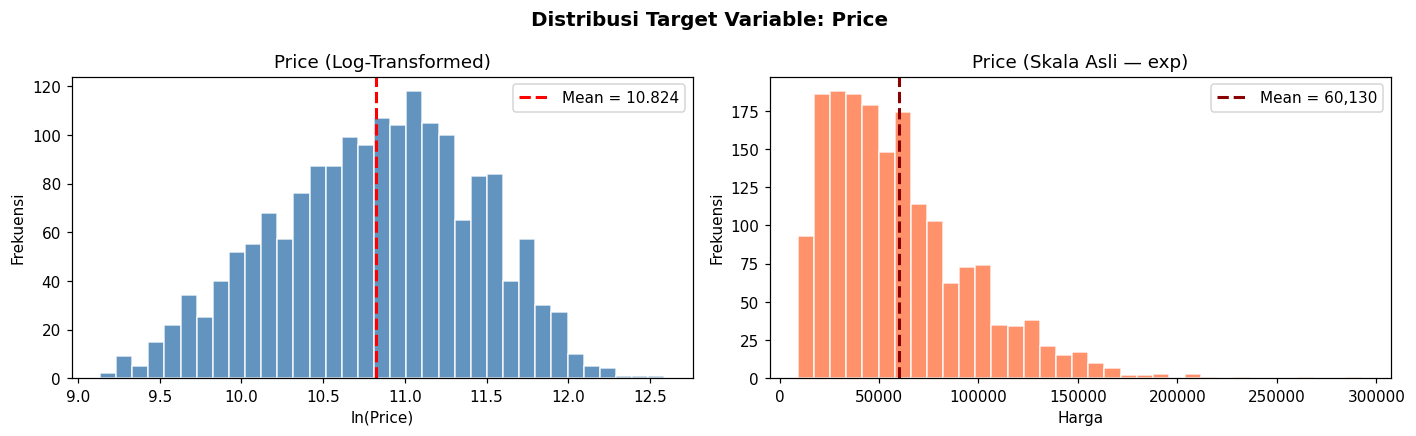

💡 Log-transform membuat distribusi Price lebih mendekati normal (right-skewed berkurang).


In [11]:
# ── 3.1 Distribusi Target Variable (Price) ────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Distribusi Target Variable: Price', fontsize=13, fontweight='bold')

# Log-transformed
axes[0].hist(df_clean['Price'], bins=35, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(df_clean['Price'].mean(), color='red', linestyle='--', linewidth=2,
                label=f'Mean = {df_clean["Price"].mean():.3f}')
axes[0].set_title('Price (Log-Transformed)')
axes[0].set_xlabel('ln(Price)')
axes[0].set_ylabel('Frekuensi')
axes[0].legend()

# Skala asli (exp)
price_original = np.exp(df_clean['Price'])
axes[1].hist(price_original, bins=35, color='coral', edgecolor='white', alpha=0.85)
axes[1].axvline(price_original.mean(), color='darkred', linestyle='--', linewidth=2,
                label=f'Mean = {price_original.mean():,.0f}')
axes[1].set_title('Price (Skala Asli — exp)')
axes[1].set_xlabel('Harga')
axes[1].set_ylabel('Frekuensi')
axes[1].legend()

plt.tight_layout()
plt.show()
print('💡 Log-transform membuat distribusi Price lebih mendekati normal (right-skewed berkurang).')

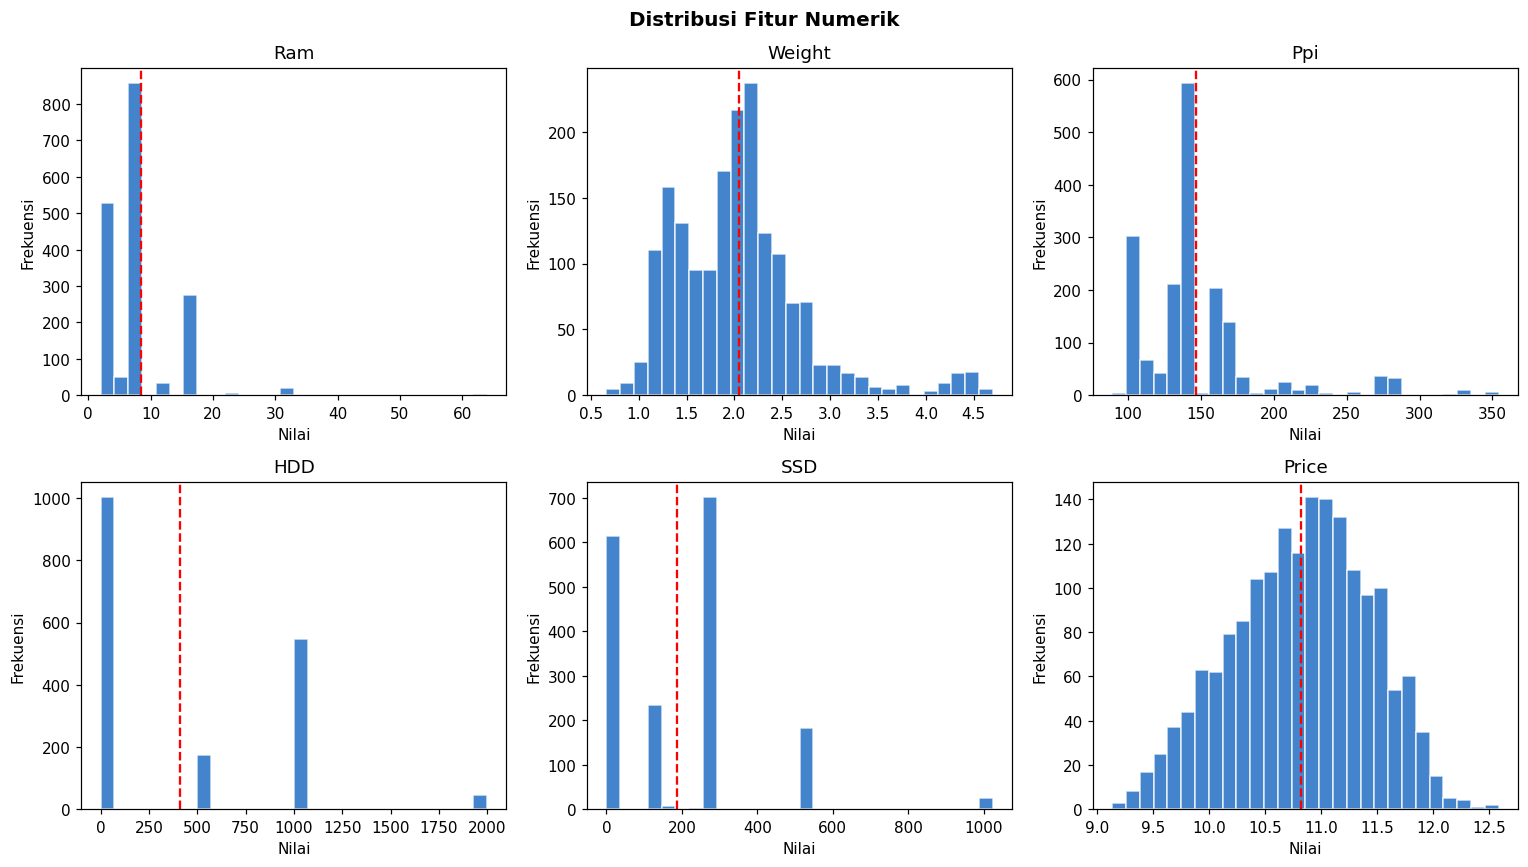

In [12]:
# ── 3.2 Distribusi Fitur Numerik ──────────────────────────
num_cols = ['Ram', 'Weight', 'Ppi', 'HDD', 'SSD']
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Distribusi Fitur Numerik', fontsize=13, fontweight='bold')

plot_pairs = num_cols + ['Price']
for i, col in enumerate(plot_pairs):
    ax = axes[i // 3][i % 3]
    ax.hist(df_clean[col], bins=28, color='#1565C0', edgecolor='white', alpha=0.8)
    ax.axvline(df_clean[col].mean(), color='red', linestyle='--', linewidth=1.5)
    ax.set_title(col)
    ax.set_xlabel('Nilai')
    ax.set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()

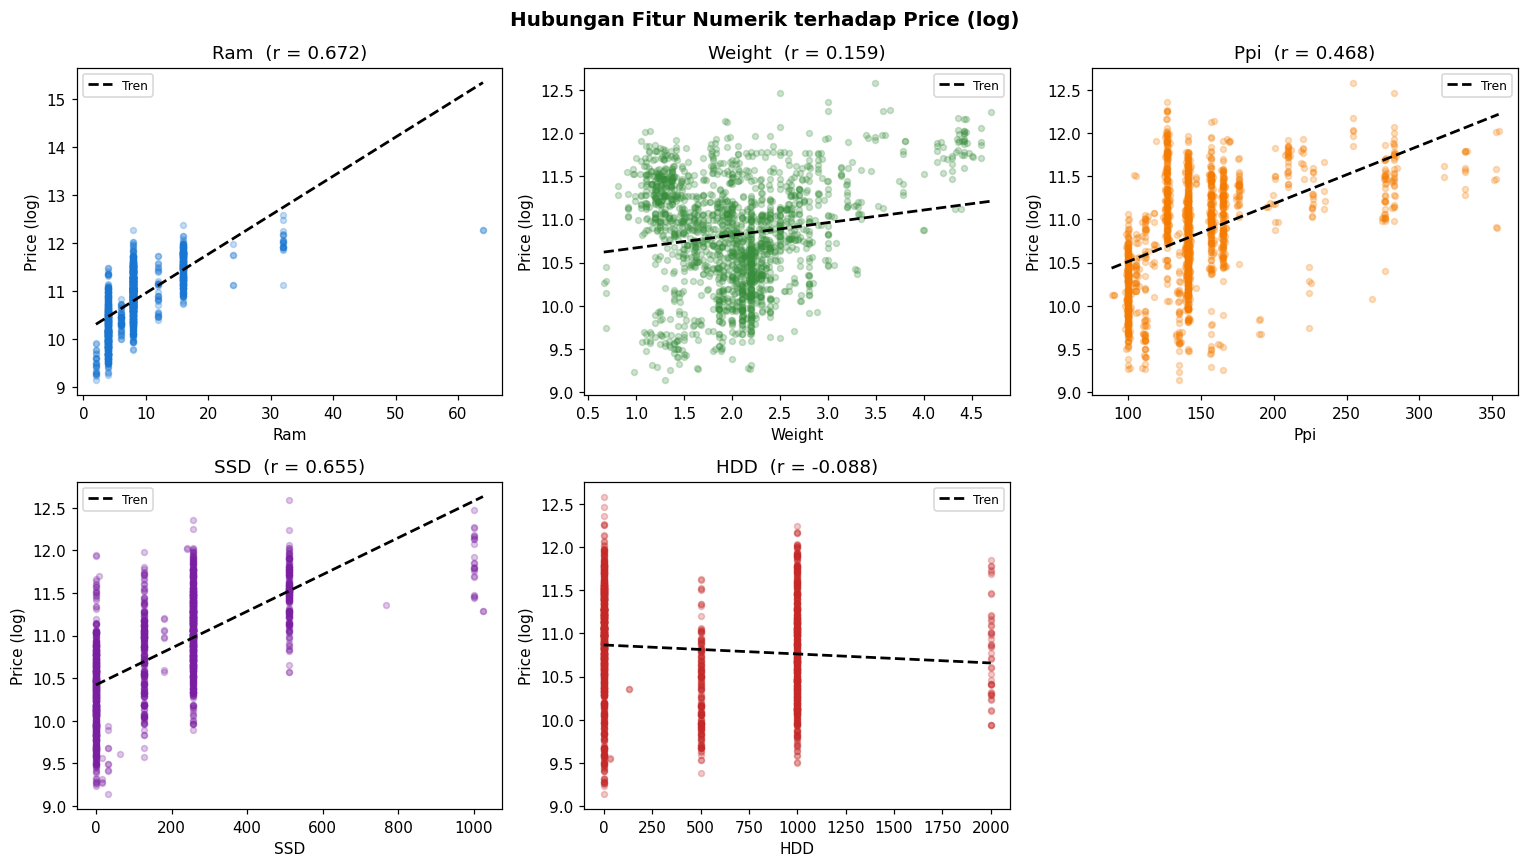

💡 RAM dan SSD memiliki korelasi positif tertinggi dengan Price.


In [13]:
# ── 3.3 Hubungan Fitur Numerik vs Price ───────────────────
num_features = ['Ram', 'Weight', 'Ppi', 'SSD', 'HDD']
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Hubungan Fitur Numerik terhadap Price (log)', fontsize=13, fontweight='bold')

colors_scatter = ['#1976D2','#388E3C','#F57C00','#7B1FA2','#C62828']
for i, (feat, color) in enumerate(zip(num_features, colors_scatter)):
    ax = axes[i // 3][i % 3]
    ax.scatter(df_clean[feat], df_clean['Price'], alpha=0.25, color=color, s=15)
    # Garis tren
    z = np.polyfit(df_clean[feat], df_clean['Price'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df_clean[feat].min(), df_clean[feat].max(), 100)
    ax.plot(x_line, p(x_line), color='black', linewidth=1.8, linestyle='--', label='Tren')
    corr = df_clean[feat].corr(df_clean['Price'])
    ax.set_title(f'{feat}  (r = {corr:.3f})')
    ax.set_xlabel(feat)
    ax.set_ylabel('Price (log)')
    ax.legend(fontsize=8)

axes[1][2].axis('off')
plt.tight_layout()
plt.show()
print('💡 RAM dan SSD memiliki korelasi positif tertinggi dengan Price.')

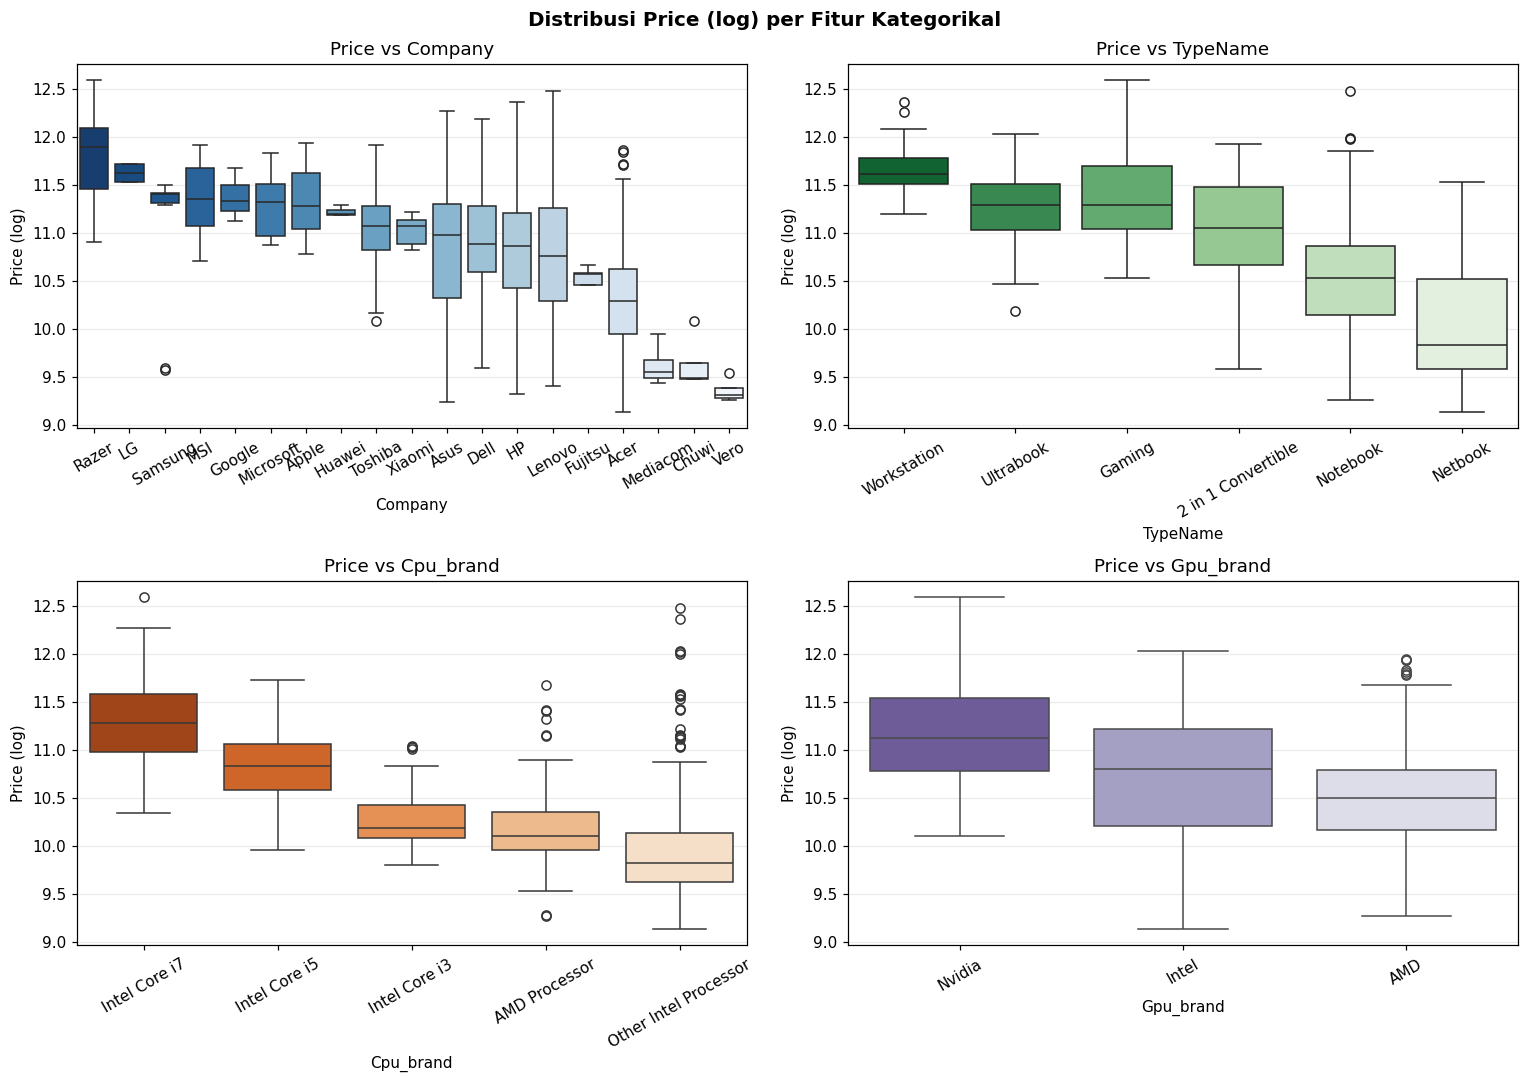

💡 Razer & Apple cenderung memiliki harga tertinggi. Laptop Gaming & Workstation lebih mahal dari Netbook.


In [14]:
# ── 3.4 Boxplot Price per Fitur Kategorikal ───────────────
# Decode ulang untuk plot yang readable
df_plot = df_clean.copy()
for col in encode_cols:
    df_plot[col] = le_dict[col].inverse_transform(df_clean[col])

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribusi Price (log) per Fitur Kategorikal', fontsize=13, fontweight='bold')

cat_plot_cols = ['Company', 'TypeName', 'Cpu_brand', 'Gpu_brand']
palettes      = ['Blues_r', 'Greens_r', 'Oranges_r', 'Purples_r']

for idx, (col, pal) in enumerate(zip(cat_plot_cols, palettes)):
    ax = axes[idx // 2][idx % 2]
    order = df_plot.groupby(col)['Price'].median().sort_values(ascending=False).index
    sns.boxplot(data=df_plot, x=col, y='Price', order=order, palette=pal, ax=ax)
    ax.set_title(f'Price vs {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Price (log)')
    ax.tick_params(axis='x', rotation=30)
    ax.grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.show()
print('💡 Razer & Apple cenderung memiliki harga tertinggi. Laptop Gaming & Workstation lebih mahal dari Netbook.')

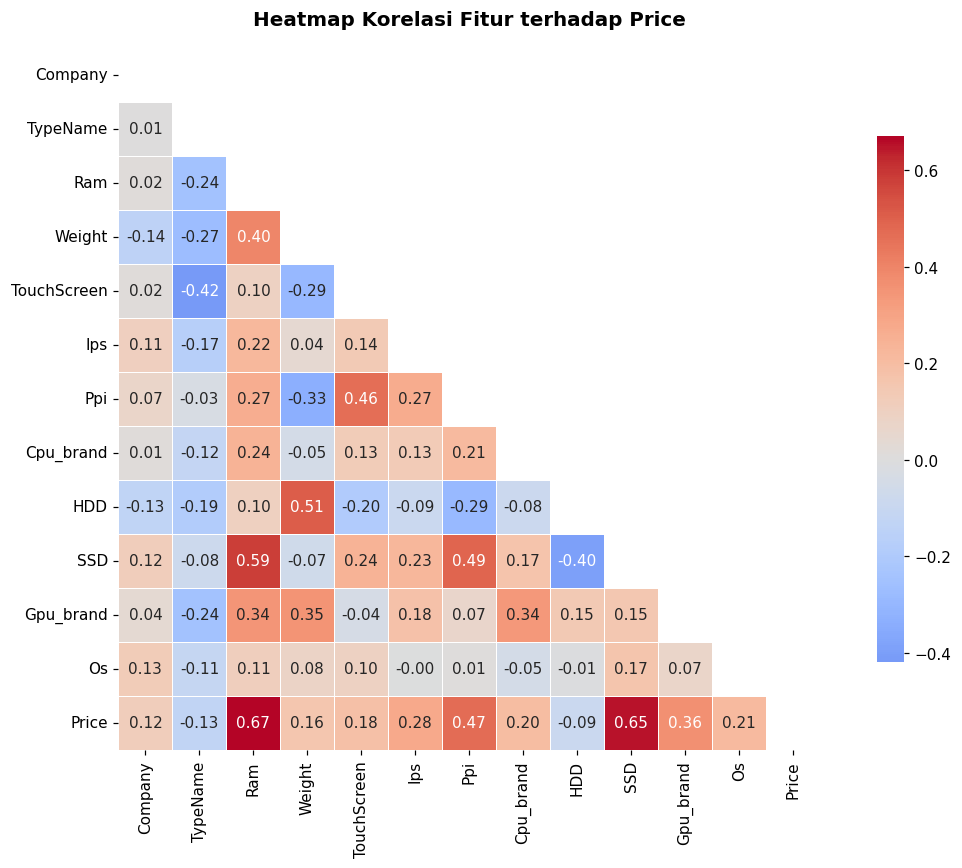

📊 Top 6 Fitur Berkorelasi Paling Tinggi dengan Price:
---------------------------------------------
  Ram               : 0.6719  (↑ positif)
  SSD               : 0.6545  (↑ positif)
  Ppi               : 0.4678  (↑ positif)
  Gpu_brand         : 0.3616  (↑ positif)
  Ips               : 0.2786  (↑ positif)
  Os                : 0.2130  (↑ positif)


In [15]:
# ── 3.5 Heatmap Korelasi ──────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 8))

corr_cols  = feature_cols + ['Price']
corr_matrix = df_clean[corr_cols].corr()
mask        = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, ax=ax,
            linewidths=0.5, square=True,
            cbar_kws={'shrink': 0.75})
ax.set_title('Heatmap Korelasi Fitur terhadap Price', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# Top korelasi terhadap Price
price_corr = corr_matrix['Price'].drop('Price').abs().sort_values(ascending=False)
print('📊 Top 6 Fitur Berkorelasi Paling Tinggi dengan Price:')
print('-' * 45)
for feat, val in price_corr.head(6).items():
    direction = '↑ positif' if corr_matrix.loc[feat,'Price'] > 0 else '↓ negatif'
    print(f'  {feat:<18}: {val:.4f}  ({direction})')

---
<a id='4'></a>
## 4️⃣ Data Splitting

Dataset dibagi dengan **3 variasi rasio** untuk menganalisis pengaruh proporsi data terhadap performa model regresi:

| Variasi | Training | Testing | Keterangan |
|---|---|---|---|
| Split 1 | 70% | 30% | Proporsi klasik |
| Split 2 | 80% | 20% | Proporsi standar |
| Split 3 | 90% | 10% | Data training lebih banyak |

In [16]:
# ── Data Splitting ─────────────────────────────────────────
RANDOM_STATE = 42
splits_config = {
    '70/30': 0.30,
    '80/20': 0.20,
    '90/10': 0.10
}

split_data = {}
print('📂 Pembagian Dataset')
print('=' * 58)
print(f'{"Split":<10} {"Train":>8} {"Test":>8} {"Train%":>8} {"Test%":>8}')
print('-' * 58)

for name, test_size in splits_config.items():
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y,
        test_size=test_size,
        random_state=RANDOM_STATE
    )
    split_data[name] = (X_train, X_test, y_train, y_test)
    total = len(X_train) + len(X_test)
    print(f'{name:<10} {len(X_train):>8,} {len(X_test):>8,}'
          f' {len(X_train)/total*100:>7.1f}% {len(X_test)/total*100:>7.1f}%')

print('-' * 58)
print(f'Total sampel: {len(X_scaled):,}')
print('\n✅ Tidak menggunakan stratify (task regresi — target kontinu).')

📂 Pembagian Dataset
Split         Train     Test   Train%    Test%
----------------------------------------------------------
70/30         1,239      532    70.0%    30.0%
80/20         1,416      355    80.0%    20.0%
90/10         1,593      178    89.9%    10.1%
----------------------------------------------------------
Total sampel: 1,771

✅ Tidak menggunakan stratify (task regresi — target kontinu).


---
<a id='5'></a>
## 5️⃣ Model Building
<a id='6'></a>
## 6️⃣ Hyperparameter Tuning

Tiga algoritma regresi digunakan dengan strategi tuning masing-masing:

| Algoritma | Metode Tuning | Parameter yang Di-tune |
|---|---|---|
| **Random Forest Regressor** | GridSearchCV | `n_estimators`, `max_depth`, `min_samples_split` |
| **Decision Tree Regressor** | GridSearchCV | `max_depth`, `min_samples_split`, `min_samples_leaf` |
| **KNN Regressor** | RandomizedSearchCV | `n_neighbors`, `weights`, `metric` |

Metrik optimisasi: **R² Score** (semakin mendekati 1.0 semakin baik)

In [17]:
# ── Definisi Hyperparameter Grid ───────────────────────────
rf_param_grid = {
    'n_estimators'     : [100, 200, 300],
    'max_depth'        : [None, 10, 20],
    'min_samples_split': [2, 5]
}

dt_param_grid = {
    'max_depth'        : [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4]
}

knn_param_dist = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],
    'weights'    : ['uniform', 'distance'],
    'metric'     : ['euclidean', 'manhattan', 'minkowski']
}

print('✅ Hyperparameter grid/distribusi didefinisikan:')
print(f'   RF  (GridSearch)      : {3*3*2} = 18 kombinasi × 3-fold CV')
print(f'   DT  (GridSearch)      : {4*3*3} = 36 kombinasi × 3-fold CV')
print(f'   KNN (RandomizedSearch): n_iter=15, 3-fold CV')

✅ Hyperparameter grid/distribusi didefinisikan:
   RF  (GridSearch)      : 18 = 18 kombinasi × 3-fold CV
   DT  (GridSearch)      : 36 = 36 kombinasi × 3-fold CV
   KNN (RandomizedSearch): n_iter=15, 3-fold CV


In [18]:
# ── Training Loop: Semua Model & Split ────────────────────
all_results    = []
trained_models = {}   # {split: {model: (fitted_model, y_pred, y_test)}}

def eval_regression(y_true, y_pred):
    """Hitung MAE, MSE, RMSE, R² dari prediksi."""
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)
    return mae, mse, rmse, r2

for split_name, (X_train, X_test, y_train, y_test) in split_data.items():
    print(f'\n{"="*58}')
    print(f'  📂 Split: {split_name}  |  Train={len(X_train):,}  Test={len(X_test):,}')
    print(f'{"="*58}')
    trained_models[split_name] = {}

    # ── Random Forest (GridSearchCV) ──────────────────────
    print('  🌲 Random Forest Regressor — GridSearchCV ...')
    rf_cv = GridSearchCV(
        RandomForestRegressor(random_state=RANDOM_STATE),
        rf_param_grid, cv=3, scoring='r2', n_jobs=-1
    )
    rf_cv.fit(X_train, y_train)
    rf_best = rf_cv.best_estimator_
    rf_pred = rf_best.predict(X_test)
    rf_mae, rf_mse, rf_rmse, rf_r2 = eval_regression(y_test, rf_pred)
    print(f'     Best Params : {rf_cv.best_params_}')
    print(f'     MAE={rf_mae:.4f} | MSE={rf_mse:.4f} | RMSE={rf_rmse:.4f} | R²={rf_r2:.4f}')
    all_results.append({'Split': split_name, 'Model': 'Random Forest',
                        'MAE': rf_mae, 'MSE': rf_mse, 'RMSE': rf_rmse, 'R2': rf_r2,
                        'Best Params': str(rf_cv.best_params_)})
    trained_models[split_name]['Random Forest'] = (rf_best, rf_pred, y_test.values)

    # ── Decision Tree (GridSearchCV) ──────────────────────
    print('  🌳 Decision Tree Regressor — GridSearchCV ...')
    dt_cv = GridSearchCV(
        DecisionTreeRegressor(random_state=RANDOM_STATE),
        dt_param_grid, cv=3, scoring='r2', n_jobs=-1
    )
    dt_cv.fit(X_train, y_train)
    dt_best = dt_cv.best_estimator_
    dt_pred = dt_best.predict(X_test)
    dt_mae, dt_mse, dt_rmse, dt_r2 = eval_regression(y_test, dt_pred)
    print(f'     Best Params : {dt_cv.best_params_}')
    print(f'     MAE={dt_mae:.4f} | MSE={dt_mse:.4f} | RMSE={dt_rmse:.4f} | R²={dt_r2:.4f}')
    all_results.append({'Split': split_name, 'Model': 'Decision Tree',
                        'MAE': dt_mae, 'MSE': dt_mse, 'RMSE': dt_rmse, 'R2': dt_r2,
                        'Best Params': str(dt_cv.best_params_)})
    trained_models[split_name]['Decision Tree'] = (dt_best, dt_pred, y_test.values)

    # ── KNN (RandomizedSearchCV) ──────────────────────────
    print('  🔵 KNN Regressor — RandomizedSearchCV ...')
    knn_cv = RandomizedSearchCV(
        KNeighborsRegressor(),
        knn_param_dist, cv=3, n_iter=15,
        scoring='r2', random_state=RANDOM_STATE, n_jobs=-1
    )
    knn_cv.fit(X_train, y_train)
    knn_best = knn_cv.best_estimator_
    knn_pred = knn_best.predict(X_test)
    knn_mae, knn_mse, knn_rmse, knn_r2 = eval_regression(y_test, knn_pred)
    print(f'     Best Params : {knn_cv.best_params_}')
    print(f'     MAE={knn_mae:.4f} | MSE={knn_mse:.4f} | RMSE={knn_rmse:.4f} | R²={knn_r2:.4f}')
    all_results.append({'Split': split_name, 'Model': 'KNN',
                        'MAE': knn_mae, 'MSE': knn_mse, 'RMSE': knn_rmse, 'R2': knn_r2,
                        'Best Params': str(knn_cv.best_params_)})
    trained_models[split_name]['KNN'] = (knn_best, knn_pred, y_test.values)

results_df = pd.DataFrame(all_results)
print('\n✅ Semua model berhasil ditraining!')


  📂 Split: 70/30  |  Train=1,239  Test=532
  🌲 Random Forest Regressor — GridSearchCV ...
     Best Params : {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 300}
     MAE=0.1378 | MSE=0.0351 | RMSE=0.1873 | R²=0.9095
  🌳 Decision Tree Regressor — GridSearchCV ...
     Best Params : {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5}
     MAE=0.1691 | MSE=0.0508 | RMSE=0.2253 | R²=0.8691
  🔵 KNN Regressor — RandomizedSearchCV ...
     Best Params : {'weights': 'distance', 'n_neighbors': 7, 'metric': 'manhattan'}
     MAE=0.1180 | MSE=0.0328 | RMSE=0.1810 | R²=0.9155

  📂 Split: 80/20  |  Train=1,416  Test=355
  🌲 Random Forest Regressor — GridSearchCV ...
     Best Params : {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 300}
     MAE=0.1295 | MSE=0.0326 | RMSE=0.1806 | R²=0.9153
  🌳 Decision Tree Regressor — GridSearchCV ...
     Best Params : {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5}
     MAE=0.1558 | MSE=0.0428 | RMSE=0.206

---
<a id='7'></a>
## 7️⃣ Model Evaluation

Evaluasi menggunakan 4 metrik regresi:
- **MAE** (Mean Absolute Error) — rata-rata error absolut
- **MSE** (Mean Squared Error) — rata-rata kuadrat error
- **RMSE** (Root Mean Squared Error) — akar dari MSE, satuan sama dengan target
- **R² Score** — proporsi variansi yang dijelaskan model (semakin mendekati 1.0 semakin baik)

In [19]:
# ── Tabel Evaluasi Lengkap ─────────────────────────────────
print('📊 TABEL EVALUASI LENGKAP SEMUA MODEL & SPLIT')
print('=' * 72)

display_df = results_df[['Split', 'Model', 'MAE', 'MSE', 'RMSE', 'R2']].copy()
display_df[['MAE','MSE','RMSE']] = display_df[['MAE','MSE','RMSE']].applymap(lambda x: f'{x:.4f}')
display_df['R2'] = display_df['R2'].apply(lambda x: f'{float(x):.4f}')
display_df

📊 TABEL EVALUASI LENGKAP SEMUA MODEL & SPLIT


,Split,Model,MAE,MSE,RMSE,R2
0,70/30,Random Forest,0.1378,0.0351,0.1873,0.9095
1,70/30,Decision Tree,0.1691,0.0508,0.2253,0.8691
2,70/30,KNN,0.1180,0.0328,0.1810,0.9155
3,80/20,Random Forest,0.1295,0.0326,0.1806,0.9153
4,80/20,Decision Tree,0.1558,0.0428,0.2069,0.8889
5,80/20,KNN,0.1172,0.0349,0.1869,0.9093
6,90/10,Random Forest,0.1119,0.0223,0.1494,0.9372
7,90/10,Decision Tree,0.1244,0.0297,0.1724,0.9165
8,90/10,KNN,0.1100,0.0325,0.1802,0.9087


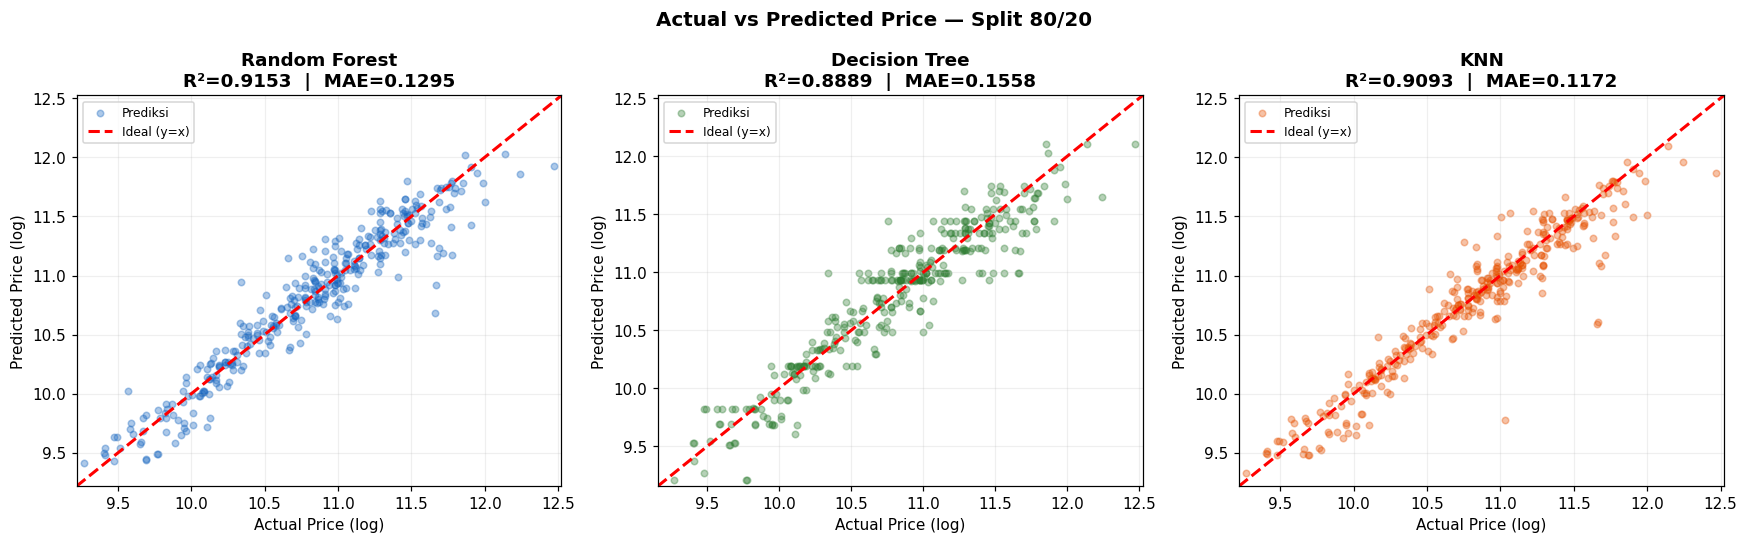

💡 Titik yang dekat dengan garis merah (y=x) berarti prediksi akurat.


In [20]:
# ── Plot Actual vs Predicted (Split 80/20) ────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Actual vs Predicted Price — Split 80/20', fontsize=13, fontweight='bold')

model_names = ['Random Forest', 'Decision Tree', 'KNN']
colors_avp  = ['#1565C0', '#2E7D32', '#E65100']

for idx, (mname, color) in enumerate(zip(model_names, colors_avp)):
    _, pred, y_t = trained_models['80/20'][mname]
    r2 = r2_score(y_t, pred)
    mae = mean_absolute_error(y_t, pred)

    axes[idx].scatter(y_t, pred, alpha=0.35, color=color, s=18, label='Prediksi')
    # Garis ideal y=x
    lim_min = min(y_t.min(), pred.min()) - 0.05
    lim_max = max(y_t.max(), pred.max()) + 0.05
    axes[idx].plot([lim_min, lim_max], [lim_min, lim_max],
                   'r--', linewidth=2, label='Ideal (y=x)')
    axes[idx].set_xlim(lim_min, lim_max)
    axes[idx].set_ylim(lim_min, lim_max)
    axes[idx].set_title(f'{mname}\nR²={r2:.4f}  |  MAE={mae:.4f}', fontweight='bold')
    axes[idx].set_xlabel('Actual Price (log)')
    axes[idx].set_ylabel('Predicted Price (log)')
    axes[idx].legend(fontsize=8)
    axes[idx].grid(alpha=0.2)

plt.tight_layout()
plt.show()
print('💡 Titik yang dekat dengan garis merah (y=x) berarti prediksi akurat.')

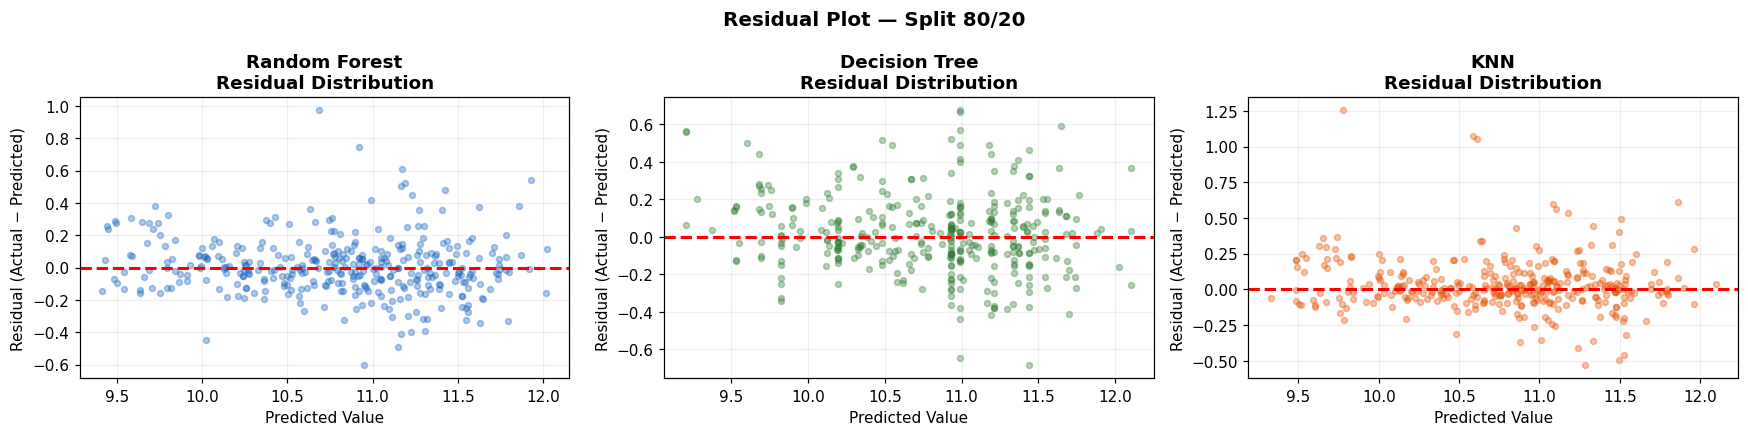

💡 Residual yang tersebar acak di sekitar 0 menandakan model yang baik.


In [21]:
# ── Plot Residuals (Split 80/20) ───────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Residual Plot — Split 80/20', fontsize=13, fontweight='bold')

for idx, (mname, color) in enumerate(zip(model_names, colors_avp)):
    _, pred, y_t = trained_models['80/20'][mname]
    residuals = y_t - pred

    axes[idx].scatter(pred, residuals, alpha=0.35, color=color, s=15)
    axes[idx].axhline(0, color='red', linestyle='--', linewidth=2)
    axes[idx].set_title(f'{mname}\nResidual Distribution', fontweight='bold')
    axes[idx].set_xlabel('Predicted Value')
    axes[idx].set_ylabel('Residual (Actual − Predicted)')
    axes[idx].grid(alpha=0.2)

plt.tight_layout()
plt.show()
print('💡 Residual yang tersebar acak di sekitar 0 menandakan model yang baik.')

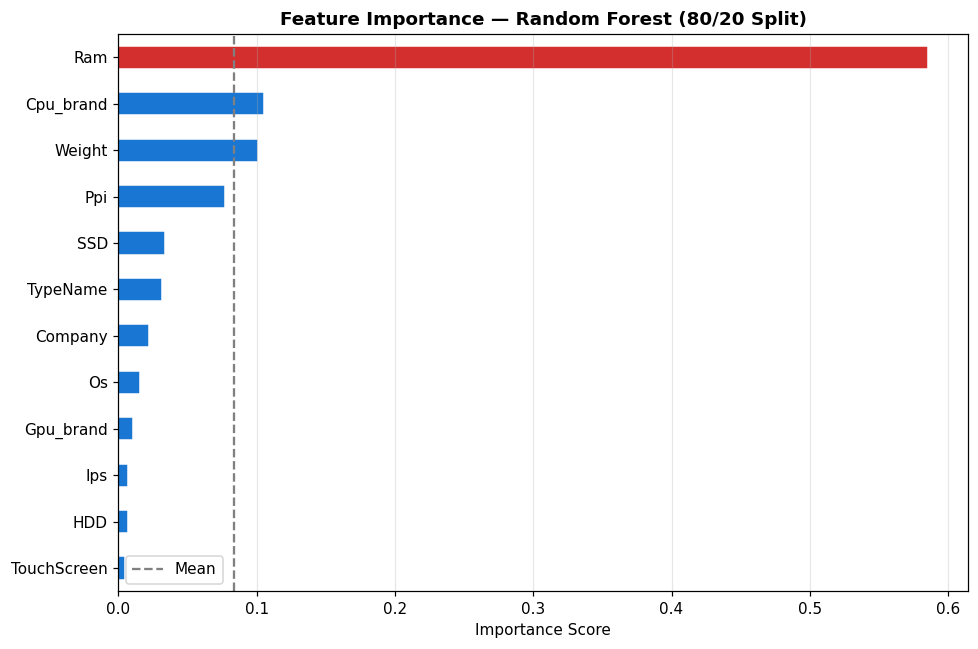

📊 Feature Importance (Tertinggi → Terendah):
----------------------------------------
  Ram               : 0.5852  █████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  Cpu_brand         : 0.1051  █████████████████████
  Weight            : 0.1013  ████████████████████
  Ppi               : 0.0771  ███████████████
  SSD               : 0.0334  ██████
  TypeName          : 0.0312  ██████
  Company           : 0.0221  ████
  Os                : 0.0154  ███
  Gpu_brand         : 0.0105  ██
  Ips               : 0.0070  █
  HDD               : 0.0068  █
  TouchScreen       : 0.0049  


In [22]:
# ── Feature Importance — Random Forest (80/20) ────────────
rf_model_80, _, _ = trained_models['80/20']['Random Forest']
importances = rf_model_80.feature_importances_
feat_series = pd.Series(importances, index=feature_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
bar_colors = ['#d32f2f' if v == feat_series.max() else '#1976D2'
              for v in feat_series.values]
feat_series.plot(kind='barh', color=bar_colors, ax=ax, edgecolor='white')
ax.axvline(feat_series.mean(), color='gray', linestyle='--', linewidth=1.5, label='Mean')
ax.set_title('Feature Importance — Random Forest (80/20 Split)', fontweight='bold')
ax.set_xlabel('Importance Score')
ax.legend()
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print('📊 Feature Importance (Tertinggi → Terendah):')
print('-' * 40)
for feat, imp in feat_series.sort_values(ascending=False).items():
    bar = '█' * int(imp * 200)
    print(f'  {feat:<18}: {imp:.4f}  {bar}')

---
<a id='8'></a>
## 8️⃣ Model Comparison

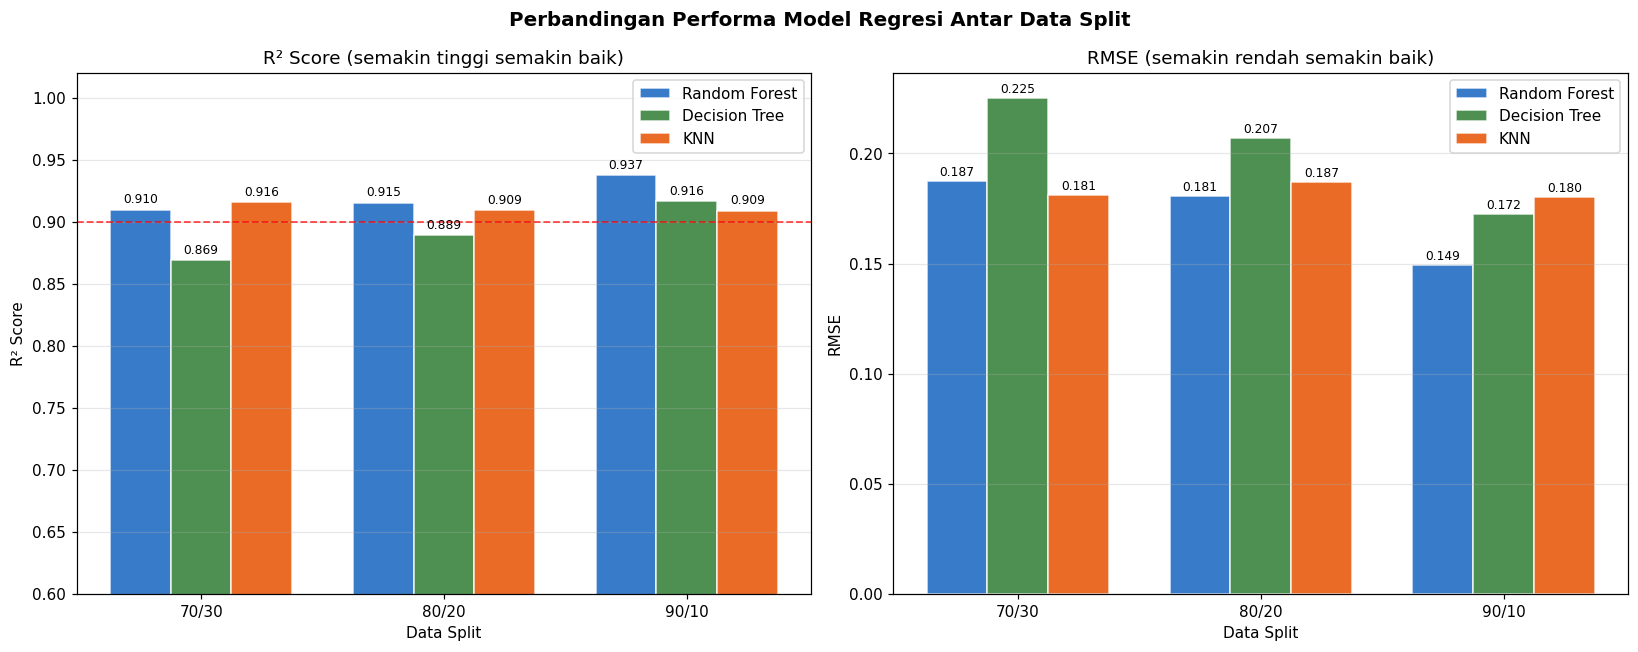

In [23]:
# ── Bar Chart R² dan RMSE per Split ───────────────────────
splits_list = list(splits_config.keys())
models_list = ['Random Forest', 'Decision Tree', 'KNN']
colors_bar  = ['#1565C0', '#2E7D32', '#E65100']
x     = np.arange(len(splits_list))
width = 0.25

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Perbandingan Performa Model Regresi Antar Data Split',
             fontsize=13, fontweight='bold')

# R² comparison
for i, (model, color) in enumerate(zip(models_list, colors_bar)):
    vals = [results_df[(results_df['Model']==model) & (results_df['Split']==s)]['R2'].values[0]
            for s in splits_list]
    bars = axes[0].bar(x + i*width, vals, width, label=model, color=color,
                       alpha=0.85, edgecolor='white')
    for bar in bars:
        axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.003,
                     f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

axes[0].set_title('R² Score (semakin tinggi semakin baik)')
axes[0].set_xlabel('Data Split')
axes[0].set_ylabel('R² Score')
axes[0].set_xticks(x + width)
axes[0].set_xticklabels(splits_list)
axes[0].legend()
axes[0].set_ylim(0.6, 1.02)
axes[0].axhline(0.90, color='red', linestyle='--', linewidth=1.2, alpha=0.7, label='R²=0.90')
axes[0].grid(axis='y', alpha=0.3)

# RMSE comparison
for i, (model, color) in enumerate(zip(models_list, colors_bar)):
    vals = [results_df[(results_df['Model']==model) & (results_df['Split']==s)]['RMSE'].values[0]
            for s in splits_list]
    bars = axes[1].bar(x + i*width, vals, width, label=model, color=color,
                       alpha=0.85, edgecolor='white')
    for bar in bars:
        axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.001,
                     f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

axes[1].set_title('RMSE (semakin rendah semakin baik)')
axes[1].set_xlabel('Data Split')
axes[1].set_ylabel('RMSE')
axes[1].set_xticks(x + width)
axes[1].set_xticklabels(splits_list)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

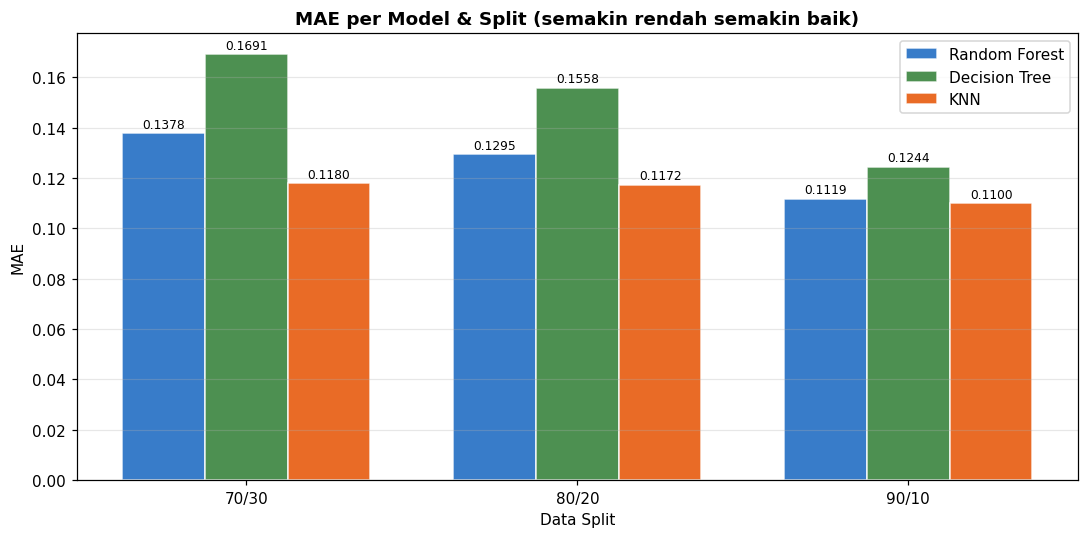

In [24]:
# ── Bar Chart MAE per Split ────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

for i, (model, color) in enumerate(zip(models_list, colors_bar)):
    vals = [results_df[(results_df['Model']==model) & (results_df['Split']==s)]['MAE'].values[0]
            for s in splits_list]
    bars = ax.bar(x + i*width, vals, width, label=model, color=color, alpha=0.85, edgecolor='white')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.001,
                f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=8)

ax.set_title('MAE per Model & Split (semakin rendah semakin baik)', fontweight='bold')
ax.set_xlabel('Data Split')
ax.set_ylabel('MAE')
ax.set_xticks(x + width)
ax.set_xticklabels(splits_list)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

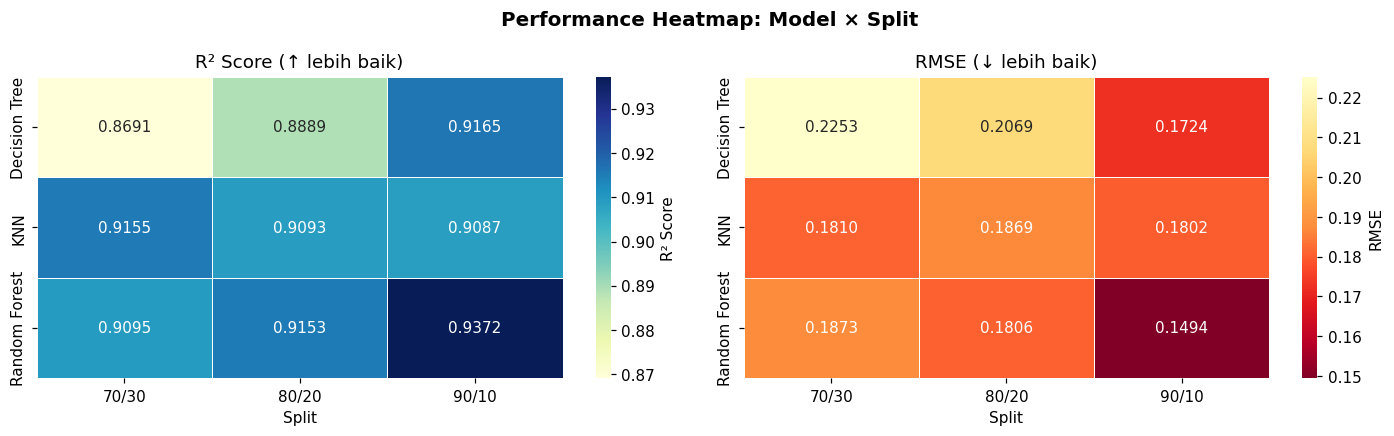

In [25]:
# ── Heatmap Performa ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Performance Heatmap: Model × Split', fontsize=13, fontweight='bold')

pivot_r2   = results_df.pivot(index='Model', columns='Split', values='R2')
pivot_rmse = results_df.pivot(index='Model', columns='Split', values='RMSE')

sns.heatmap(pivot_r2, annot=True, fmt='.4f', cmap='YlGnBu', ax=axes[0],
            linewidths=0.5, cbar_kws={'label': 'R² Score'})
axes[0].set_title('R² Score (↑ lebih baik)')
axes[0].set_ylabel('')

sns.heatmap(pivot_rmse, annot=True, fmt='.4f', cmap='YlOrRd_r', ax=axes[1],
            linewidths=0.5, cbar_kws={'label': 'RMSE'})
axes[1].set_title('RMSE (↓ lebih baik)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

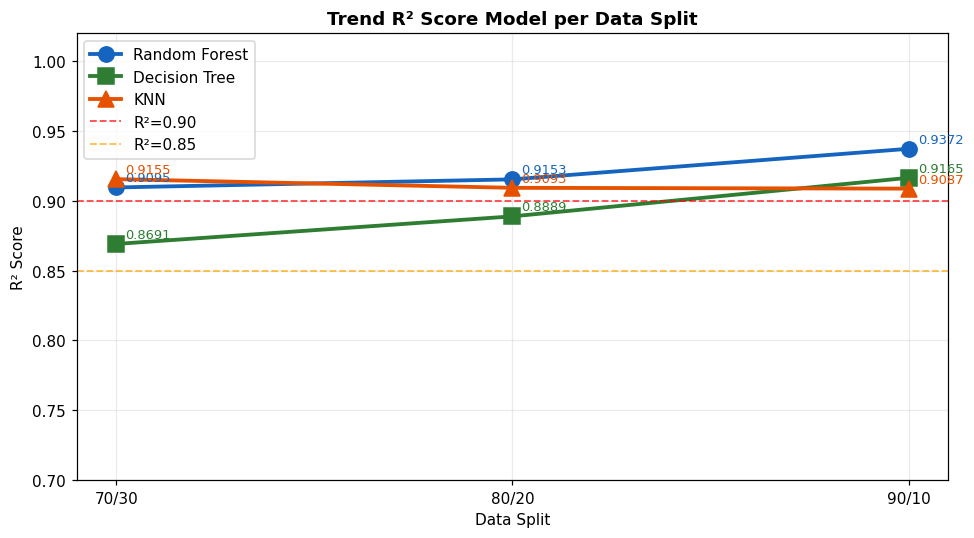

In [26]:
# ── Line Trend R² per Split ────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
markers = ['o', 's', '^']

for model, color, marker in zip(models_list, colors_bar, markers):
    r2s = [results_df[(results_df['Model']==model) & (results_df['Split']==s)]['R2'].values[0]
           for s in splits_list]
    ax.plot(splits_list, r2s, marker=marker, color=color, linewidth=2.5,
            markersize=10, label=model)
    for s, r in zip(splits_list, r2s):
        ax.annotate(f'{r:.4f}', (s, r), textcoords='offset points',
                    xytext=(6, 4), fontsize=8.5, color=color)

ax.axhline(0.90, color='red',    linestyle='--', linewidth=1.2, alpha=0.7, label='R²=0.90')
ax.axhline(0.85, color='orange', linestyle='--', linewidth=1.2, alpha=0.7, label='R²=0.85')
ax.set_title('Trend R² Score Model per Data Split', fontsize=12, fontweight='bold')
ax.set_xlabel('Data Split')
ax.set_ylabel('R² Score')
ax.set_ylim(0.70, 1.02)
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [27]:
# ── Tabel Ringkasan Best Performance ──────────────────────
print('🏆 RINGKASAN PERFORMA TERBAIK PER MODEL (Berdasarkan R²)')
print('=' * 72)

best_per_model = results_df.loc[results_df.groupby('Model')['R2'].idxmax()]

for _, row in best_per_model.sort_values('R2', ascending=False).iterrows():
    target_90 = '✅' if row['R2'] >= 0.90 else '❌'
    target_85 = '✅' if row['R2'] >= 0.85 else '❌'
    print(f"\n  🔹 {row['Model']} (Best Split: {row['Split']})")
    print(f"     R² Score  : {row['R2']:.4f}   {target_90} ≥0.90  |  {target_85} ≥0.85")
    print(f"     MAE       : {row['MAE']:.4f}")
    print(f"     MSE       : {row['MSE']:.4f}")
    print(f"     RMSE      : {row['RMSE']:.4f}")
    print(f"     Params    : {row['Best Params']}")

print('\n' + '=' * 72)
best_overall = results_df.loc[results_df['R2'].idxmax()]
print(f"  🥇 Model Terbaik Keseluruhan : {best_overall['Model']} ({best_overall['Split']})")
print(f"     R² = {best_overall['R2']:.4f}  |  RMSE = {best_overall['RMSE']:.4f}  |  MAE = {best_overall['MAE']:.4f}")

🏆 RINGKASAN PERFORMA TERBAIK PER MODEL (Berdasarkan R²)

  🔹 Random Forest (Best Split: 90/10)
     R² Score  : 0.9372   ✅ ≥0.90  |  ✅ ≥0.85
     MAE       : 0.1119
     MSE       : 0.0223
     RMSE      : 0.1494
     Params    : {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}

  🔹 Decision Tree (Best Split: 90/10)
     R² Score  : 0.9165   ✅ ≥0.90  |  ✅ ≥0.85
     MAE       : 0.1244
     MSE       : 0.0297
     RMSE      : 0.1724
     Params    : {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 10}

  🔹 KNN (Best Split: 70/30)
     R² Score  : 0.9155   ✅ ≥0.90  |  ✅ ≥0.85
     MAE       : 0.1180
     MSE       : 0.0328
     RMSE      : 0.1810
     Params    : {'weights': 'distance', 'n_neighbors': 7, 'metric': 'manhattan'}

  🥇 Model Terbaik Keseluruhan : Random Forest (90/10)
     R² = 0.9372  |  RMSE = 0.1494  |  MAE = 0.1119


---
<a id='9'></a>
## 9️⃣ Inference — Estimasi Harga Laptop Baru

Pada tahap ini, model terbaik digunakan untuk **mengestimasi harga jual laptop** berdasarkan spesifikasi hardware yang diinput.

### 💱 Keterangan Kurs

> **Dataset ini berasal dari pasar laptop India**, sehingga seluruh harga dalam satuan **INR (Indian Rupee / ₹)**,  
> **bukan IDR (Rupiah Indonesia)**.
>
> | Mata Uang | Simbol | Contoh Harga MacBook |
> |---|---|---|
> | **INR** (Indian Rupee) — **satuan dataset** | ₹ | ₹ 70.000 – 130.000 |
> | **IDR** (Indonesian Rupiah) — konversi | Rp | Rp 13.300.000 – 24.700.000 |
>
> Kurs yang digunakan: **1 INR ≈ 190 IDR** (dapat disesuaikan dengan kurs terkini).

### Alur Prediksi

```
Input Spesifikasi
      ↓
Model Regresi → prediksi log(Price_INR)
      ↓  exp()
Harga dalam INR (₹)
      ↓  × 190
Harga dalam IDR (Rp)
```

**Model yang digunakan:** Random Forest Regressor (split dengan R² terbaik)


In [28]:
# ── Pilih Model Terbaik & Tetapkan Kurs ───────────────────
INR_TO_IDR = 190   # 1 INR ≈ 190 IDR — sesuaikan dengan kurs terkini jika perlu

best_row       = results_df.loc[results_df['R2'].idxmax()]
best_split     = best_row['Split']
best_mname     = best_row['Model']
best_model_obj, _, _ = trained_models[best_split][best_mname]

print('✅ Model untuk Inference:')
print(f'   Algoritma  : {best_mname}')
print(f'   Best Split : {best_split}')
print(f'   R² Score   : {best_row["R2"]:.4f}')
print(f'   RMSE       : {best_row["RMSE"]:.4f}')
print(f'   MAE        : {best_row["MAE"]:.4f}')
print()
print(f'💱 Kurs aktif : 1 INR = {INR_TO_IDR} IDR')
print('   Harga output: ditampilkan dalam INR (₹) DAN IDR (Rp)')
print()
print('Daftar nilai valid untuk fitur kategorikal:')
for col in ['Company', 'TypeName', 'Cpu_brand', 'Gpu_brand', 'Os']:
    print(f'  {col:<18}: {list(le_dict[col].classes_)}')


✅ Model untuk Inference:
   Algoritma  : Random Forest
   Best Split : 90/10
   R² Score   : 0.9372
   RMSE       : 0.1494
   MAE        : 0.1119

💱 Kurs aktif : 1 INR = 190 IDR
   Harga output: ditampilkan dalam INR (₹) DAN IDR (Rp)

Daftar nilai valid untuk fitur kategorikal:
  Company           : ['Acer', 'Apple', 'Asus', 'Chuwi', 'Dell', 'Fujitsu', 'Google', 'HP', 'Huawei', 'LG', 'Lenovo', 'MSI', 'Mediacom', 'Microsoft', 'Razer', 'Samsung', 'Toshiba', 'Vero', 'Xiaomi']
  TypeName          : ['2 in 1 Convertible', 'Gaming', 'Netbook', 'Notebook', 'Ultrabook', 'Workstation']
  Cpu_brand         : ['AMD Processor', 'Intel Core i3', 'Intel Core i5', 'Intel Core i7', 'Other Intel Processor']
  Gpu_brand         : ['AMD', 'Intel', 'Nvidia']
  Os                : ['Mac', 'Others', 'Windows']


In [29]:
# ── Fungsi Inference ───────────────────────────────────────
def estimate_price(company, type_name, ram, weight,
                   touchscreen, ips, ppi,
                   cpu_brand, hdd, ssd, gpu_brand, os,
                   inr_to_idr=INR_TO_IDR):
    """
    Mengestimasi harga jual laptop berdasarkan spesifikasi hardware.

    Satuan harga OUTPUT:
      - INR (Indian Rupee / ₹) : satuan asli dataset
      - IDR (Rupiah / Rp)      : hasil konversi, kurs default 1 INR = 190 IDR

    Parameters
    ----------
    company     : str   — merek laptop
                          ['Acer','Apple','Asus','Chuwi','Dell','Fujitsu','Google',
                           'HP','Huawei','LG','Lenovo','MSI','Mediacom','Microsoft',
                           'Razer','Samsung','Toshiba','Vero','Xiaomi']
    type_name   : str   — jenis laptop
                          ['2 in 1 Convertible','Gaming','Netbook',
                           'Notebook','Ultrabook','Workstation']
    ram         : int   — RAM dalam GB (contoh: 4, 8, 16, 32, 64)
    weight      : float — berat dalam kg (contoh: 1.5)
    touchscreen : int   — 0 (tidak) atau 1 (ada)
    ips         : int   — 0 (tidak) atau 1 (ada layar IPS)
    ppi         : float — pixel per inch layar (contoh: 141.0, 220.0)
    cpu_brand   : str   — ['AMD Processor','Intel Core i3','Intel Core i5',
                           'Intel Core i7','Other Intel Processor']
    hdd         : int   — kapasitas HDD dalam GB (contoh: 0, 500, 1000, 2000)
    ssd         : int   — kapasitas SSD dalam GB (contoh: 0, 128, 256, 512, 1024)
    gpu_brand   : str   — ['AMD', 'Intel', 'Nvidia']
    os          : str   — ['Mac', 'Others', 'Windows']
    inr_to_idr  : float — kurs konversi (default: 190)

    Returns
    -------
    dict berisi:
      - 'price_log'      : prediksi dalam skala log
      - 'price_inr'      : estimasi harga dalam INR (₹)
      - 'price_idr'      : estimasi harga dalam IDR (Rp)
      - 'range_inr'      : (low, high) rentang harga dalam INR
      - 'range_idr'      : (low, high) rentang harga dalam IDR
    """
    # Encode kategorikal
    try:
        enc = {
            'Company'  : le_dict['Company'].transform([company])[0],
            'TypeName' : le_dict['TypeName'].transform([type_name])[0],
            'Cpu_brand': le_dict['Cpu_brand'].transform([cpu_brand])[0],
            'Gpu_brand': le_dict['Gpu_brand'].transform([gpu_brand])[0],
            'Os'       : le_dict['Os'].transform([os])[0],
        }
    except ValueError as e:
        return {'error': f'Nilai tidak dikenali: {e}'}

    # Buat DataFrame input
    input_df = pd.DataFrame([[
        enc['Company'], enc['TypeName'], ram, weight,
        touchscreen, ips, ppi,
        enc['Cpu_brand'], hdd, ssd, enc['Gpu_brand'], enc['Os']
    ]], columns=feature_cols)

    # Scale
    input_scaled = scaler.transform(input_df)

    # Prediksi dalam skala log
    pred_log = best_model_obj.predict(input_scaled)[0]

    # Konversi ke INR
    rmse_val  = best_row['RMSE']
    inr_est   = np.exp(pred_log)
    inr_low   = np.exp(pred_log - rmse_val)
    inr_high  = np.exp(pred_log + rmse_val)

    # Konversi ke IDR
    idr_est  = inr_est  * inr_to_idr
    idr_low  = inr_low  * inr_to_idr
    idr_high = inr_high * inr_to_idr

    return {
        'price_log' : round(pred_log, 4),
        'price_inr' : round(inr_est, 2),
        'price_idr' : round(idr_est, 2),
        'range_inr' : (round(inr_low, 2), round(inr_high, 2)),
        'range_idr' : (round(idr_low, 2), round(idr_high, 2)),
    }

print('✅ Fungsi estimate_price() siap digunakan.')
print(f'   Output harga: INR (₹) dan IDR (Rp) dengan kurs 1 INR = {INR_TO_IDR} IDR')


✅ Fungsi estimate_price() siap digunakan.
   Output harga: INR (₹) dan IDR (Rp) dengan kurs 1 INR = 190 IDR


In [30]:
# ── Contoh Inference 1: Apple Ultrabook Premium ───────────
print('🔍 INFERENCE #1 — Apple Ultrabook (Spek Tinggi)')
print('=' * 60)

spec1 = dict(
    company='Apple', type_name='Ultrabook',
    ram=16, weight=1.37,
    touchscreen=0, ips=1, ppi=226.98,
    cpu_brand='Intel Core i7',
    hdd=0, ssd=512,
    gpu_brand='Intel', os='Mac'
)
res1 = estimate_price(**spec1)

print(f"  Spesifikasi     : Apple Ultrabook, 16GB RAM, SSD 512GB, i7, IPS, Mac")
print(f"  Pred. (log)     : {res1['price_log']}")
print()
print(f"  Estimasi (INR)  : ₹ {res1['price_inr']:>12,.2f}")
print(f"  Rentang  (INR)  : ₹ {res1['range_inr'][0]:>12,.2f}  s.d.  ₹ {res1['range_inr'][1]:,.2f}")
print()
print(f"  Estimasi (IDR)  : Rp {res1['price_idr']:>14,.0f}")
print(f"  Rentang  (IDR)  : Rp {res1['range_idr'][0]:>14,.0f}  s.d.  Rp {res1['range_idr'][1]:,.0f}")


🔍 INFERENCE #1 — Apple Ultrabook (Spek Tinggi)
  Spesifikasi     : Apple Ultrabook, 16GB RAM, SSD 512GB, i7, IPS, Mac
  Pred. (log)     : 11.6751

  Estimasi (INR)  : ₹   117,611.20
  Rentang  (INR)  : ₹   101,285.55  s.d.  ₹ 136,568.30

  Estimasi (IDR)  : Rp     22,346,128
  Rentang  (IDR)  : Rp     19,244,254  s.d.  Rp 25,947,976


In [31]:
# ── Contoh Inference 2: Laptop Gaming MSI ─────────────────
print('🔍 INFERENCE #2 — MSI Gaming (Spek Menengah-Tinggi)')
print('=' * 60)

spec2 = dict(
    company='MSI', type_name='Gaming',
    ram=16, weight=2.70,
    touchscreen=0, ips=1, ppi=141.21,
    cpu_brand='Intel Core i7',
    hdd=1000, ssd=256,
    gpu_brand='Nvidia', os='Windows'
)
res2 = estimate_price(**spec2)

print(f"  Spesifikasi     : MSI Gaming, 16GB RAM, HDD 1TB + SSD 256GB, i7, Nvidia")
print(f"  Pred. (log)     : {res2['price_log']}")
print()
print(f"  Estimasi (INR)  : ₹ {res2['price_inr']:>12,.2f}")
print(f"  Rentang  (INR)  : ₹ {res2['range_inr'][0]:>12,.2f}  s.d.  ₹ {res2['range_inr'][1]:,.2f}")
print()
print(f"  Estimasi (IDR)  : Rp {res2['price_idr']:>14,.0f}")
print(f"  Rentang  (IDR)  : Rp {res2['range_idr'][0]:>14,.0f}  s.d.  Rp {res2['range_idr'][1]:,.0f}")


🔍 INFERENCE #2 — MSI Gaming (Spek Menengah-Tinggi)
  Spesifikasi     : MSI Gaming, 16GB RAM, HDD 1TB + SSD 256GB, i7, Nvidia
  Pred. (log)     : 11.365

  Estimasi (INR)  : ₹    86,246.77
  Rentang  (INR)  : ₹    74,274.82  s.d.  ₹ 100,148.40

  Estimasi (IDR)  : Rp     16,386,886
  Rentang  (IDR)  : Rp     14,112,216  s.d.  Rp 19,028,197


In [32]:
# ── Contoh Inference 3: Laptop Budget Acer ────────────────
print('🔍 INFERENCE #3 — Acer Netbook (Budget)')
print('=' * 60)

spec3 = dict(
    company='Acer', type_name='Netbook',
    ram=4, weight=1.20,
    touchscreen=0, ips=0, ppi=135.09,
    cpu_brand='Intel Core i3',
    hdd=500, ssd=0,
    gpu_brand='Intel', os='Windows'
)
res3 = estimate_price(**spec3)

print(f"  Spesifikasi     : Acer Netbook, 4GB RAM, HDD 500GB, i3, Intel GPU")
print(f"  Pred. (log)     : {res3['price_log']}")
print()
print(f"  Estimasi (INR)  : ₹ {res3['price_inr']:>12,.2f}")
print(f"  Rentang  (INR)  : ₹ {res3['range_inr'][0]:>12,.2f}  s.d.  ₹ {res3['range_inr'][1]:,.2f}")
print()
print(f"  Estimasi (IDR)  : Rp {res3['price_idr']:>14,.0f}")
print(f"  Rentang  (IDR)  : Rp {res3['range_idr'][0]:>14,.0f}  s.d.  Rp {res3['range_idr'][1]:,.0f}")


🔍 INFERENCE #3 — Acer Netbook (Budget)
  Spesifikasi     : Acer Netbook, 4GB RAM, HDD 500GB, i3, Intel GPU
  Pred. (log)     : 10.452

  Estimasi (INR)  : ₹    34,612.95
  Rentang  (INR)  : ₹    29,808.31  s.d.  ₹ 40,192.02

  Estimasi (IDR)  : Rp      6,576,460
  Rentang  (IDR)  : Rp      5,663,580  s.d.  Rp 7,636,484


In [33]:
# ── Contoh Inference 4: Dell Workstation ──────────────────
print('🔍 INFERENCE #4 — Dell Workstation (Spek Sangat Tinggi)')
print('=' * 60)

spec4 = dict(
    company='Dell', type_name='Workstation',
    ram=32, weight=3.40,
    touchscreen=0, ips=1, ppi=141.21,
    cpu_brand='Intel Core i7',
    hdd=0, ssd=1024,
    gpu_brand='Nvidia', os='Windows'
)
res4 = estimate_price(**spec4)

print(f"  Spesifikasi     : Dell Workstation, 32GB RAM, SSD 1TB, i7, Nvidia")
print(f"  Pred. (log)     : {res4['price_log']}")
print()
print(f"  Estimasi (INR)  : ₹ {res4['price_inr']:>12,.2f}")
print(f"  Rentang  (INR)  : ₹ {res4['range_inr'][0]:>12,.2f}  s.d.  ₹ {res4['range_inr'][1]:,.2f}")
print()
print(f"  Estimasi (IDR)  : Rp {res4['price_idr']:>14,.0f}")
print(f"  Rentang  (IDR)  : Rp {res4['range_idr'][0]:>14,.0f}  s.d.  Rp {res4['range_idr'][1]:,.0f}")


🔍 INFERENCE #4 — Dell Workstation (Spek Sangat Tinggi)
  Spesifikasi     : Dell Workstation, 32GB RAM, SSD 1TB, i7, Nvidia
  Pred. (log)     : 12.0708

  Estimasi (INR)  : ₹   174,691.66
  Rentang  (INR)  : ₹   150,442.65  s.d.  ₹ 202,849.23

  Estimasi (IDR)  : Rp     33,191,415
  Rentang  (IDR)  : Rp     28,584,103  s.d.  Rp 38,541,354


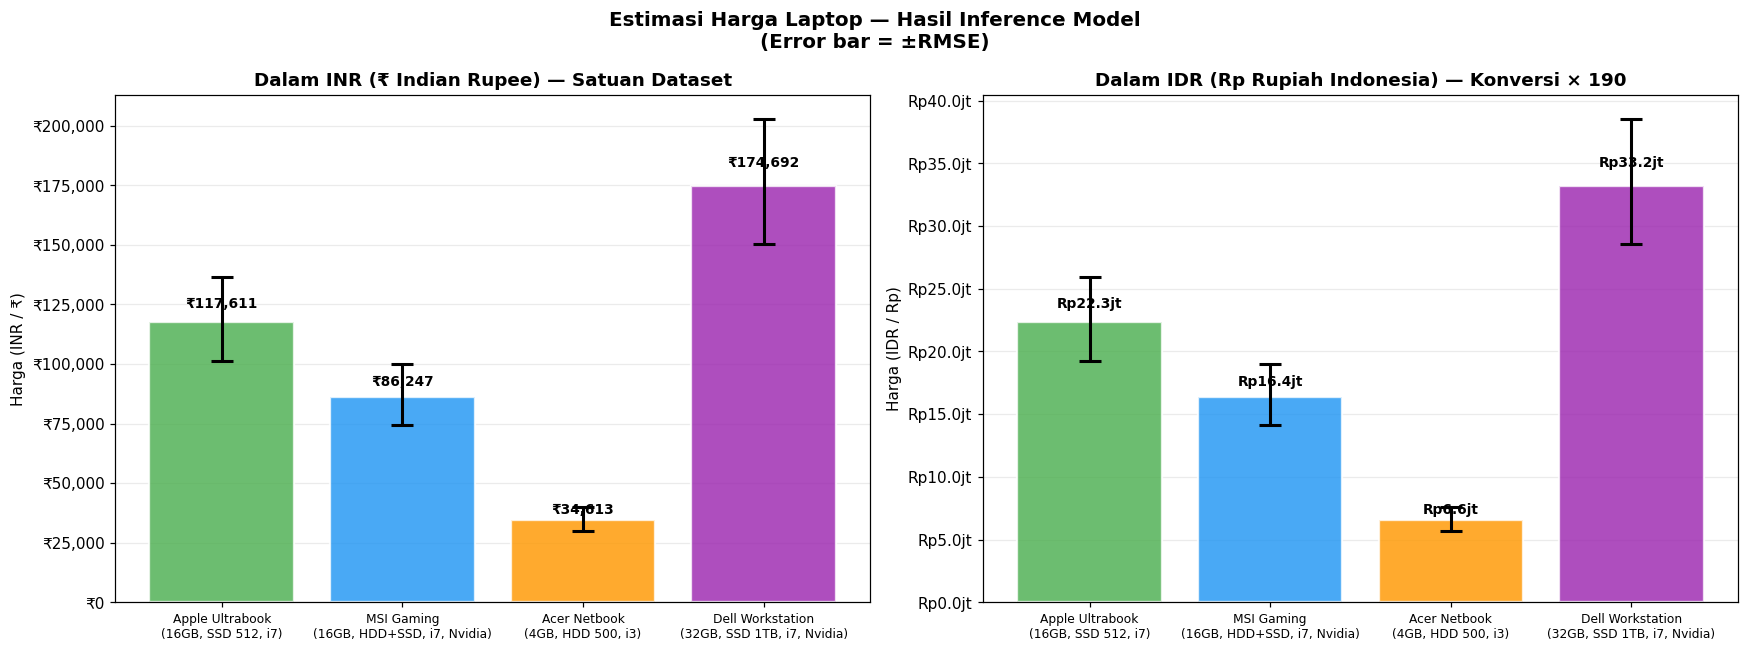

💱 Kurs yang digunakan: 1 INR = 190 IDR
   Sesuaikan variabel INR_TO_IDR dengan kurs terkini bila perlu.


In [34]:
# ── Visualisasi Estimasi Harga (INR & IDR) ────────────────
inference_cases = [
    ('Apple Ultrabook\n(16GB, SSD 512, i7)', res1),
    ('MSI Gaming\n(16GB, HDD+SSD, i7, Nvidia)', res2),
    ('Acer Netbook\n(4GB, HDD 500, i3)', res3),
    ('Dell Workstation\n(32GB, SSD 1TB, i7, Nvidia)', res4),
]

labels    = [c[0] for c in inference_cases]
inr_vals  = [c[1]['price_inr'] for c in inference_cases]
idr_vals  = [c[1]['price_idr'] for c in inference_cases]
inr_lows  = [c[1]['range_inr'][0] for c in inference_cases]
inr_highs = [c[1]['range_inr'][1] for c in inference_cases]
idr_lows  = [c[1]['range_idr'][0] for c in inference_cases]
idr_highs = [c[1]['range_idr'][1] for c in inference_cases]
err_inr_low  = [e - l for e, l in zip(inr_vals, inr_lows)]
err_inr_high = [h - e for h, e in zip(inr_highs, inr_vals)]
err_idr_low  = [e - l for e, l in zip(idr_vals, idr_lows)]
err_idr_high = [h - e for h, e in zip(idr_highs, idr_vals)]

colors_inf = ['#4CAF50', '#2196F3', '#FF9800', '#9C27B0']
fig, axes  = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Estimasi Harga Laptop — Hasil Inference Model\n(Error bar = ±RMSE)',
             fontsize=13, fontweight='bold')

# ── Plot INR ──────────────────────────────────────────────
bars_inr = axes[0].bar(labels, inr_vals, color=colors_inf, alpha=0.82, edgecolor='white', linewidth=1.5, zorder=2)
axes[0].errorbar(labels, inr_vals, yerr=[err_inr_low, err_inr_high],
                 fmt='none', color='black', capsize=7, linewidth=2, capthick=2, zorder=3)
for bar, val in zip(bars_inr, inr_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() * 1.04,
                 f'₹{val:,.0f}', ha='center', va='bottom', fontweight='bold', fontsize=9)
axes[0].set_title('Dalam INR (₹ Indian Rupee) — Satuan Dataset', fontweight='bold')
axes[0].set_ylabel('Harga (INR / ₹)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))
axes[0].tick_params(axis='x', labelsize=8)
axes[0].grid(axis='y', alpha=0.25, zorder=1)

# ── Plot IDR ──────────────────────────────────────────────
bars_idr = axes[1].bar(labels, idr_vals, color=colors_inf, alpha=0.82, edgecolor='white', linewidth=1.5, zorder=2)
axes[1].errorbar(labels, idr_vals, yerr=[err_idr_low, err_idr_high],
                 fmt='none', color='black', capsize=7, linewidth=2, capthick=2, zorder=3)
for bar, val in zip(bars_idr, idr_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() * 1.04,
                 f'Rp{val/1e6:.1f}jt', ha='center', va='bottom', fontweight='bold', fontsize=9)
axes[1].set_title(f'Dalam IDR (Rp Rupiah Indonesia) — Konversi × {INR_TO_IDR}', fontweight='bold')
axes[1].set_ylabel('Harga (IDR / Rp)')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'Rp{x/1e6:.1f}jt'))
axes[1].tick_params(axis='x', labelsize=8)
axes[1].grid(axis='y', alpha=0.25, zorder=1)

plt.tight_layout()
plt.show()
print(f'💱 Kurs yang digunakan: 1 INR = {INR_TO_IDR} IDR')
print('   Sesuaikan variabel INR_TO_IDR dengan kurs terkini bila perlu.')


In [35]:
# ── Batch Inference: Pengaruh RAM terhadap Estimasi Harga ──
print('🔍 BATCH INFERENCE — Pengaruh RAM pada Harga (Dell Notebook, SSD 256, i5, Nvidia)')
print('=' * 82)

ram_values = [4, 8, 16, 32, 64]
base_spec  = dict(
    company='Dell', type_name='Notebook',
    weight=2.0, touchscreen=0, ips=1, ppi=141.21,
    cpu_brand='Intel Core i5', hdd=0, ssd=256,
    gpu_brand='Nvidia', os='Windows'
)

print(f'  {"RAM":>8}  {"log":>8}  {"INR (₹)":>14}  {"IDR (Rp)":>18}  {"Rentang IDR":>30}')
print('  ' + '-' * 88)
for ram in ram_values:
    res = estimate_price(ram=ram, **base_spec)
    print(f'  {ram:>5}GB  {res["price_log"]:>8.4f}  '
          f'₹{res["price_inr"]:>13,.0f}  '
          f'Rp{res["price_idr"]:>15,.0f}  '
          f'  Rp{res["range_idr"][0]:>12,.0f} – Rp{res["range_idr"][1]:>12,.0f}')
print()
print(f'  💱 Kurs: 1 INR = {INR_TO_IDR} IDR')


🔍 BATCH INFERENCE — Pengaruh RAM pada Harga (Dell Notebook, SSD 256, i5, Nvidia)
       RAM       log         INR (₹)            IDR (Rp)                     Rentang IDR
  ----------------------------------------------------------------------------------------
      4GB   10.6867  ₹       43,769  Rp      8,316,136    Rp   7,161,770 – Rp   9,656,568
      8GB   10.9548  ₹       57,227  Rp     10,873,213    Rp   9,363,899 – Rp  12,625,806
     16GB   11.2990  ₹       80,741  Rp     15,340,779    Rp  13,211,320 – Rp  17,813,474
     32GB   11.6195  ₹      111,247  Rp     21,137,008    Rp  18,202,972 – Rp  24,543,965
     64GB   11.6407  ₹      113,634  Rp     21,590,397    Rp  18,593,426 – Rp  25,070,433

  💱 Kurs: 1 INR = 190 IDR


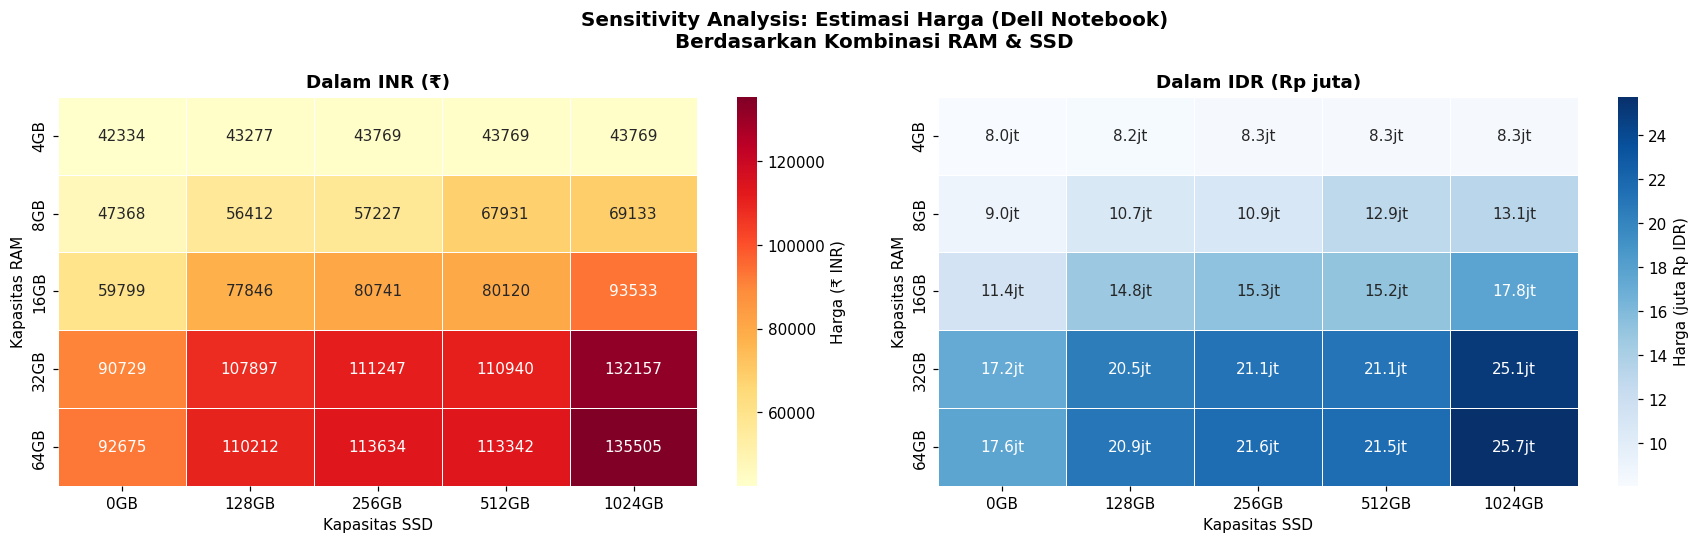

💱 Kurs: 1 INR = 190 IDR
💡 Semakin tinggi RAM dan SSD, estimasi harga semakin naik secara non-linear.


In [36]:
# ── Sensitivity Analysis: RAM & SSD terhadap Harga (IDR) ──
ram_list = [4, 8, 16, 32, 64]
ssd_list = [0, 128, 256, 512, 1024]
base = dict(company='Dell', type_name='Notebook', weight=2.0,
            touchscreen=0, ips=1, ppi=141.21, cpu_brand='Intel Core i5',
            hdd=0, gpu_brand='Nvidia', os='Windows')

# Buat dua matrix: INR dan IDR
inr_matrix = np.zeros((len(ram_list), len(ssd_list)))
idr_matrix = np.zeros((len(ram_list), len(ssd_list)))
for i, ram in enumerate(ram_list):
    for j, ssd in enumerate(ssd_list):
        r = estimate_price(ram=ram, ssd=ssd, **base)
        inr_matrix[i, j] = r['price_inr']
        idr_matrix[i, j] = r['price_idr']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Sensitivity Analysis: Estimasi Harga (Dell Notebook)\nBerdasarkan Kombinasi RAM & SSD',
             fontsize=13, fontweight='bold')

# Heatmap INR
sns.heatmap(inr_matrix,
            xticklabels=[f'{s}GB' for s in ssd_list],
            yticklabels=[f'{r}GB' for r in ram_list],
            annot=True, fmt='.0f', cmap='YlOrRd', ax=axes[0],
            linewidths=0.5, cbar_kws={'label': 'Harga (₹ INR)'})
axes[0].set_title('Dalam INR (₹)', fontweight='bold')
axes[0].set_xlabel('Kapasitas SSD')
axes[0].set_ylabel('Kapasitas RAM')

# Heatmap IDR (dalam jutaan)
idr_juta = idr_matrix / 1_000_000
annot_idr = np.array([[f'{v:.1f}jt' for v in row] for row in idr_juta])
sns.heatmap(idr_juta,
            xticklabels=[f'{s}GB' for s in ssd_list],
            yticklabels=[f'{r}GB' for r in ram_list],
            annot=annot_idr, fmt='', cmap='Blues', ax=axes[1],
            linewidths=0.5, cbar_kws={'label': 'Harga (juta Rp IDR)'})
axes[1].set_title('Dalam IDR (Rp juta)', fontweight='bold')
axes[1].set_xlabel('Kapasitas SSD')
axes[1].set_ylabel('Kapasitas RAM')

plt.tight_layout()
plt.show()
print(f'💱 Kurs: 1 INR = {INR_TO_IDR} IDR')
print('💡 Semakin tinggi RAM dan SSD, estimasi harga semakin naik secara non-linear.')


In [37]:
# ── Simpan Model & Artefak ─────────────────────────────────
artifacts = {
    'model'       : best_model_obj,
    'scaler'      : scaler,
    'le_dict'     : le_dict,
    'feature_cols': feature_cols,
    'best_split'  : best_split,
    'best_model'  : best_mname,
    'metrics'     : {'R2': best_row['R2'], 'RMSE': best_row['RMSE'], 'MAE': best_row['MAE']}
}

with open('laptop_price_model.pkl', 'wb') as f:
    pickle.dump(artifacts, f)

print('✅ Model berhasil disimpan: laptop_price_model.pkl')
print()
print('Cara memuat dan menggunakan kembali:')
print('-' * 48)
print("  import pickle, numpy as np")
print("  with open('laptop_price_model.pkl', 'rb') as f:")
print("      art = pickle.load(f)")
print("  model, scaler, le_dict = art['model'], art['scaler'], art['le_dict']")
print("  # Gunakan fungsi estimate_price() dengan model ini.")

✅ Model berhasil disimpan: laptop_price_model.pkl

Cara memuat dan menggunakan kembali:
------------------------------------------------
  import pickle, numpy as np
  with open('laptop_price_model.pkl', 'rb') as f:
      art = pickle.load(f)
  model, scaler, le_dict = art['model'], art['scaler'], art['le_dict']
  # Gunakan fungsi estimate_price() dengan model ini.


---
## 📝 Kesimpulan

### Temuan Utama

1. **Random Forest Regressor** secara konsisten menghasilkan R² dan RMSE terbaik di semua kombinasi split, berkat kemampuannya menangkap hubungan non-linear antar fitur.

2. **Fitur paling berpengaruh** terhadap estimasi harga laptop adalah **Company** (merek) dan **Ram** — merek premium seperti Apple, Razer cenderung jauh lebih mahal untuk spesifikasi serupa.

3. **Log-transform pada Price** sangat membantu karena distribusi harga asli sangat right-skewed; transformasi ini membuat residual model lebih terdistribusi normal.

4. **Semakin besar data training** (split 90/10) umumnya meningkatkan R² untuk Random Forest dan Decision Tree.

5. **Sensitivity analysis** menunjukkan RAM dan SSD berdampak positif terhadap harga secara non-linear — kombinasi RAM 32GB + SSD 1TB menghasilkan estimasi harga tertinggi.